
**Lead University · Ciencia de Datos · Minería de Datos I**

**Temas:** PCA, ACM, t-SNE, UMAP y Clustering

---

# Parte I. Preguntas

---

## 1. Objetivo principal del PCA y una situación donde sea útil

El PCA resume muchas variables numéricas en unas pocas componentes nuevas (combinaciones lineales de las originales) que conservan la mayor variabilidad posible y no están correlacionadas entre sí. Es útil, por ejemplo, cuando tengo un dataset de clientes con 30 indicadores de consumo y necesito visualizar en dos ejes cómo se parecen entre ellos, algo imposible de graficar en 30 dimensiones.

---

## 2. Qué representa la varianza explicada y cómo usar la acumulada

La varianza explicada es el porcentaje de la variabilidad total de los datos que captura esa componente, o sea cuánta información alcanzó a resumir ese eje. La acumulada suma las primeras componentes, y con ella se decide cuántas conservar: se van sumando hasta llegar a un umbral aceptable de información retenida (por lo general 70-80%, según la tolerancia del análisis).

---

## 3. Por qué estandarizar antes de aplicar PCA

Porque el PCA trabaja sobre la varianza y esta depende de la escala de cada variable. Si tengo edad en años junto con ingreso en dólares, el ingreso domina la primera componente solo porque sus números son más grandes, no porque importe más. Al estandarizar, todas quedan con media 0 y desviación 1, así compiten en igualdad de condiciones.

---

## 4. Qué representa una componente principal y por qué no es una variable original

Es un eje nuevo trazado en la dirección donde los datos tienen más variabilidad; el primero maximiza la varianza y los siguientes se trazan ortogonales para no repetir información. No corresponde a ninguna variable original porque es una combinación lineal de todas, cada una con su propio peso y por eso hay que leer las cargas para ponerle un nombre con sentido.

---

## 5. Objetivo del ACM y tipo de variables apropiadas

El ACM busca lo mismo que el PCA: reducir dimensiones para poder visualizar e interpretar pero sobre variables **cualitativas** y de tres en adelante (con dos sería un ACS). Codifica las categorías en una tabla de 0 y 1 y trabaja con frecuencias y distancia chi-cuadrado, para mostrar en un mapa 2D cuáles categorías van juntas y cuáles individuos comparten perfil.

---

## 6. Diferencia fundamental entre PCA y ACM

La diferencia está en el tipo de dato y por lo tanto en la matemática de partida: el PCA analiza variables **numéricas** a partir de la matriz de covarianza/correlación, midiendo variabilidad y correlaciones lineales. El ACM analiza variables **cualitativas** a partir de frecuencias, midiendo asociaciones entre categorías con distancia chi-cuadrado e inercia.

---

## 7. Cómo funciona K-Means y qué es el centroide

K-Means arranca colocando $k$ centroides al azar y luego repite dos pasos: asigna cada punto al centroide más cercano y recalcula cada centroide como el promedio de los puntos que le quedaron. Eso se repite hasta que los centroides dejan de moverse. El **centroide** es ese punto promedio del cluster, su centro geométrico, y es lo que después se interpreta como el perfil del grupo.

---

## 8. Propósito del método del codo (Elbow Method)

Sirve para elegir el número de clusters, sobre todo en K-Means donde $k$ es obligatorio. Se grafica la **inercia** (suma de distancias al cuadrado de cada punto a su centroide) contra distintos valores de $k$: como la inercia siempre baja, no se busca el mínimo sino el punto donde la curva deja de caer fuerte y se aplana. Ese quiebre es el codo; después de ahí solo se hipersegmenta.

---

## 9. Qué mide el Silhouette Score y cómo se interpreta

Mide qué tan bien ubicado está cada punto en su cluster, comparando su distancia promedio al propio grupo contra la del grupo vecino más cercano. Cerca de **1**: clusters compactos y bien separados. Cerca de **0**: el punto está en la frontera y su asignación es ambigua. **Negativo**: está más cerca del cluster vecino que del suyo, probablemente quedó mal clasificado.

---

## 10. K-Means vs. DBSCAN

K-Means agrupa por distancia a centroides: hay que definir $k$, asigna todos los puntos y funciona bien con grupos compactos y esféricos. DBSCAN agrupa por **densidad**: no necesita saber cuántos clusters hay, detecta formas de cualquier tipo y marca como ruido lo que no cae en una región densa. Por eso es más apropiado en detección de anomalías (fraude, piezas defectuosas), donde justamente los outliers son el hallazgo valioso.

---

## 11. Qué es t-SNE, su propósito y su diferencia con PCA

t-SNE es una técnica de reducción **no lineal** cuyo propósito es visualizar en 2D cómo se agrupan los individuos: convierte las distancias en probabilidades de vecindad y va moviendo los puntos hasta que el mapa reproduzca esas relaciones. A diferencia del PCA, que es lineal, determinístico y reporta varianza explicada, t-SNE es estocástico, no tiene esa métrica y sus ejes no significan nada interpretable, pero separa mucho mejor los grupos cuando la estructura no es lineal.

---

## 12. Qué es UMAP y su diferencia con PCA en cuanto a estructura preservada

UMAP es otra técnica **no lineal**: para cada punto identifica sus vecinos cercanos, arma un grafo con esas relaciones y luego optimiza posiciones en 2D respetando ese grafo. La diferencia clave con PCA es qué preservan: el PCA preserva la estructura lineal de la varianza (direcciones de máxima variabilidad), mientras UMAP preserva las **vecindades**, tanto locales como globales, sin garantizar linealidad ni reportar varianza explicada.

---

## 13. Cómo funciona el clustering jerárquico aglomerativo y el dendrograma

Es *bottom-up*: cada observación empieza como su propio cluster y en cada paso se fusionan los dos grupos más cercanos según el criterio de enlace, hasta quedar todo en un solo cluster. El **dendrograma** es el árbol que guarda esa secuencia, donde la altura indica a qué distancia ocurrió cada fusión. Para decidir el número de clusters se traza una línea horizontal y se cuentan las ramas cortadas, idealmente justo debajo de un salto grande de altura.

---

## 14. Qué determina un criterio de enlace y por qué cambia el resultado

El criterio de enlace define cómo se mide la distancia entre dos **clusters**, no entre dos puntos: *single* usa el par más cercano, *complete* el más lejano, *average* el promedio de todos los pares y *Ward* el par que menos aumente la varianza interna. Como cada regla mide la cercanía de forma distinta, cambia el orden de las fusiones y con eso los clusters finales, aun con el mismo dataset. Además cada uno tiene su sesgo de forma: single tiende a cadenas alargadas, Ward y complete a grupos compactos.

---

## 15. Cómo elegir la mejor solución de clustering sin etiquetas reales

Sin etiquetas no hay accuracy que comparar, así que se recurre a **métricas internas** que evalúan qué tan compactos y separados quedaron los grupos, y se elige la configuración con el mejor valor. Dos que se pueden usar:

- **Silhouette Score:** compara la distancia de cada punto a su propio cluster contra la del vecino más cercano; indica cohesión y separación, y delata los individuos mal clasificados.
- **Criterio de Fisher ($J = L/d$):** relaciona la separación entre centroides con la dispersión interna de los clusters. Entre mayor $J$, mejor la partición; solo sirve para comparar configuraciones entre sí.

Conviene además revisar antes con **Hopkins** o **VAT** que el dataset sea clusterizable, porque si no hay estructura la "mejor" solución igual es un invento.

# Parte II. Desarrollo y aplicación

## Librerías y scripts

In [171]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from scripts import (
    GraficosCuantitativos,
    PCAAnalysis,
    codo_jambu,
    silhouette_kmeans,
    bar_plot,
    bar_plot_detail,
    radar_plot,
)
from scripts.clustering_jerarquico_utils import (
    agregaciones,
    altura_corte,
    plot_dendrograma_cortes,
)

sns.set_theme(style='whitegrid', palette='Set2')
SEED = 42

---

# Caso 1. Segmentación de vinos mediante reducción de dimensionalidad y clustering

**Objetivo:** determinar si las características fisicoquímicas de los vinos permiten identificar grupos naturales de observaciones.

**Ruta del análisis:** exploración → selección de variables → estandarización → PCA → elección de componentes → K-Means sobre las componentes → validación del número de clusters con dos criterios → interpretación de los grupos con las variables originales.

## a) Carga y exploración inicial

In [172]:
wine = pd.read_csv('datos/winequality.csv')

print(f'Observaciones: {wine.shape[0]}   |   Variables: {wine.shape[1]}')
wine.head()

Observaciones: 1599   |   Variables: 12


,fija.acidez,volatil.acidez,citrica.acidez,residual.azucar,cloruros,libre.sulfuro.dioxido,total.sulfuro.dioxido,densidad,pH,sulfitos,alcohol,calidad
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [173]:
wine.info()

print('\nValores faltantes por variable:')
print(wine.isnull().sum())

print(f'\nFilas duplicadas exactas: {wine.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fija.acidez            1599 non-null   float64
 1   volatil.acidez         1599 non-null   float64
 2   citrica.acidez         1599 non-null   float64
 3   residual.azucar        1599 non-null   float64
 4   cloruros               1599 non-null   float64
 5   libre.sulfuro.dioxido  1599 non-null   float64
 6   total.sulfuro.dioxido  1599 non-null   float64
 7   densidad               1599 non-null   float64
 8   pH                     1599 non-null   float64
 9   sulfitos               1599 non-null   float64
 10  alcohol                1599 non-null   float64
 11  calidad                1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Valores faltantes por variable:
fija.acidez              0
volatil.acidez           0
citrica.acidez           

In [174]:
wine.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fija.acidez,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatil.acidez,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citrica.acidez,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual.azucar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
cloruros,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
libre.sulfuro.dioxido,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total.sulfuro.dioxido,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
densidad,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulfitos,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


calidad
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


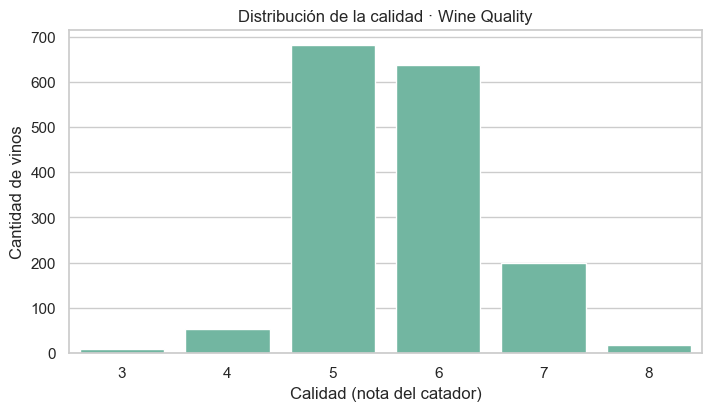

In [175]:
# Distribución de la variable calidad (no entra al modelo, se revisa para conocer el dataset)
print(wine['calidad'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
sns.countplot(x='calidad', data=wine, ax=ax)
ax.set_title('Distribución de la calidad · Wine Quality')
ax.set_xlabel('Calidad (nota del catador)')
ax.set_ylabel('Cantidad de vinos')
plt.show()

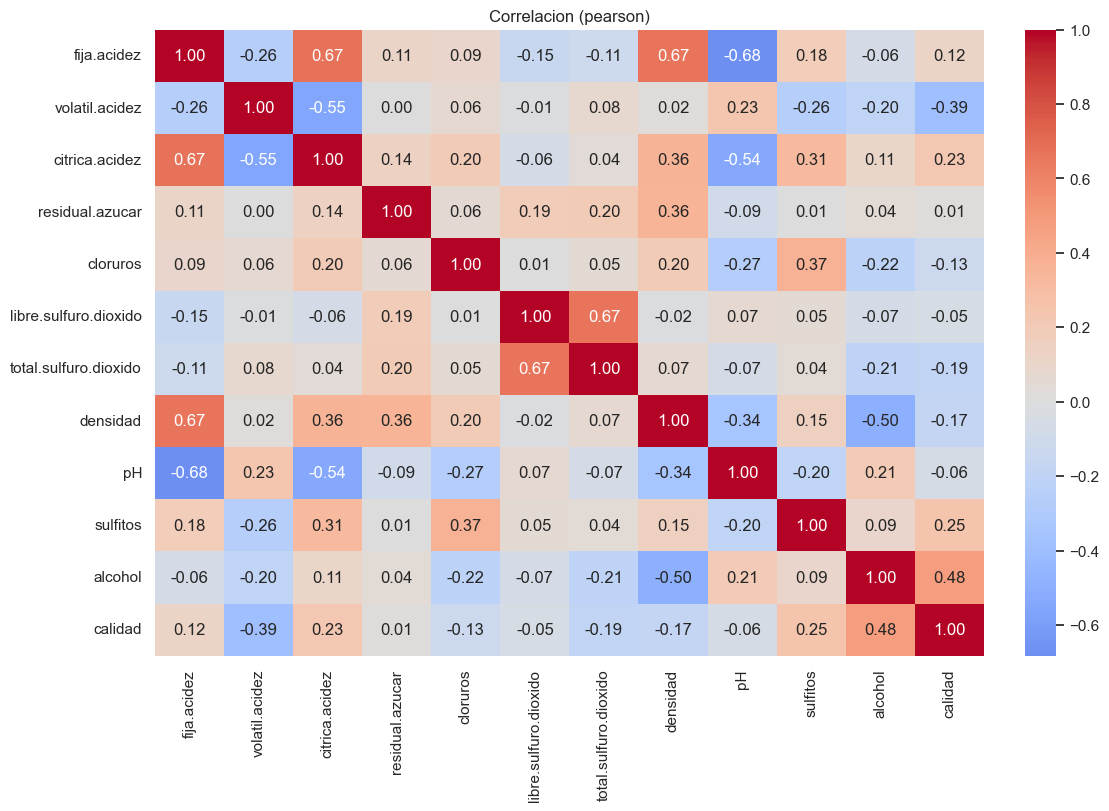

Correlación de calidad con cada variable:
alcohol                  0.476
sulfitos                 0.251
citrica.acidez           0.226
fija.acidez              0.124
residual.azucar          0.014
libre.sulfuro.dioxido   -0.051
pH                      -0.058
cloruros                -0.129
densidad                -0.175
total.sulfuro.dioxido   -0.185
volatil.acidez          -0.391
Name: calidad, dtype: float64


In [176]:
# Matriz de correlación de las variables fisicoquímicas
graficos = GraficosCuantitativos(wine)

fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
graficos.heatmap_correlacion(ax=ax)
plt.show()
# Correlación de la calidad con cada variable fisicoquímica.
# La calidad no entra al modelo, pero este dato se retoma al interpretar los clusters.
print('Correlación de calidad con cada variable:')
print(wine.corr()['calidad'].drop('calidad').sort_values(ascending=False).round(3))

### Interpretación

El dataset trae **1 599 vinos tintos** descritos por **11 variables fisicoquímicas** más la columna `calidad`, todas numéricas y **sin ningún valor faltante**. El problema de calidad que sí aparece son **240 filas duplicadas exactas**, y hay diferencias de escala enormes: el dióxido de azufre total va de 6 a 289 mientras la densidad se mueve entre 0.990 y 1.004.

La calidad está muy desbalanceada: 681 vinos con nota 5 y 638 con nota 6 concentran el 82% del total, mientras las notas extremas (3 y 8) juntan apenas 28 casos. Esto ya adelanta que no conviene esperar que los grupos que salgan del clustering se correspondan con la calidad.

En la matriz de correlación se ven bloques de variables que hablan de lo mismo, que es justamente lo que el PCA aprovecha: acidez fija con acidez cítrica (0.67) y con densidad (0.67), acidez fija con pH (−0.68, lógico porque más ácido es menos pH), y dióxido de azufre libre con total (0.67).

De la calidad conviene anotar desde ya con qué se relaciona, porque se retoma al final: la variable más asociada en positivo es el **alcohol (0.48)** y la más asociada en negativo la **acidez volátil (−0.39)**. Ninguna correlación es fuerte, así que ya se ve que la calidad no va a explicarse con una sola medición.

## b) Selección de variables

Se trabaja con las **11 variables fisicoquímicas** y se **excluye `calidad`**.

In [177]:
FEATURES = [c for c in wine.columns if c != 'calidad']

print('Variables que entran al análisis no supervisado:')
for v in FEATURES:
    print(f'  · {v}')
print(f'\nTotal: {len(FEATURES)} variables   |   Excluida: calidad')

Variables que entran al análisis no supervisado:
  · fija.acidez
  · volatil.acidez
  · citrica.acidez
  · residual.azucar
  · cloruros
  · libre.sulfuro.dioxido
  · total.sulfuro.dioxido
  · densidad
  · pH
  · sulfitos
  · alcohol

Total: 11 variables   |   Excluida: calidad


### Interpretación

`calidad` se deja fuera por dos razones. La primera es conceptual: es la **nota que le pone un catador**, o sea un juicio sensorial externo, no una característica fisicoquímica del vino; meterla como entrada convertiría el ejercicio en algo a medio camino entre supervisado y no supervisado. La segunda es que el objetivo del caso es ver si **las características fisicoquímicas por sí solas** generan grupos naturales, es decir, si le paso la calidad al algoritmo, ya no puedo responder eso.

Además es una variable ordinal con solo 6 niveles y muy desbalanceada, así que en una distancia euclidiana aportaría poco y de forma distorsionada. Se guarda para el final como **variable de validación externa**: al terminar, se cruza con los clusters para ver si los grupos químicos tienen alguna relación con la calidad percibida.

Las 11 variables fisicoquímicas se conservan todas: aunque algunas están correlacionadas entre sí, esa redundancia es precisamente lo que el PCA resuelve, así que no hace falta descartar ninguna a mano.

## c) Preparación de los datos

In [178]:
# Se eliminan los duplicados exactos: no aportan información nueva y pesan doble en los centroides
wine_mod = wine.drop_duplicates().reset_index(drop=True)
print(f'Filas antes: {len(wine)}   |   después de quitar duplicados: {len(wine_mod)}')

# Revisión de atípicos extremos con el criterio de 3 × IQR
Q1, Q3 = wine_mod[FEATURES].quantile(0.25), wine_mod[FEATURES].quantile(0.75)
IQR = Q3 - Q1
mask_out = ((wine_mod[FEATURES] < Q1 - 3 * IQR) | (wine_mod[FEATURES] > Q3 + 3 * IQR)).any(axis=1)
print(f'Filas con al menos un atípico extremo (3×IQR): {mask_out.sum()}')

Filas antes: 1599   |   después de quitar duplicados: 1359
Filas con al menos un atípico extremo (3×IQR): 139


In [179]:
# Comprobación de por qué hace falta estandarizar
X = StandardScaler().fit_transform(wine_mod[FEATURES])

comparacion = pd.DataFrame({
    'media_original': wine_mod[FEATURES].mean(),
    'desv_original': wine_mod[FEATURES].std(),
    'varianza_original': wine_mod[FEATURES].var(),
    'desv_estandarizada': X.std(axis=0),
}).round(3)
comparacion

,media_original,desv_original,varianza_original,desv_estandarizada
fija.acidez,8.311,1.737,3.017,1.0
volatil.acidez,0.529,0.183,0.034,1.0
citrica.acidez,0.272,0.196,0.038,1.0
residual.azucar,2.523,1.352,1.829,1.0
cloruros,0.088,0.049,0.002,1.0
libre.sulfuro.dioxido,15.893,10.447,109.145,1.0
total.sulfuro.dioxido,46.826,33.409,1116.158,1.0
densidad,0.997,0.002,0.000,1.0
pH,3.310,0.155,0.024,1.0
sulfitos,0.659,0.171,0.029,1.0


### Interpretación

Se quitan los **240 duplicados exactos** y quedan **1 359 vinos**. Un duplicado no aporta información nueva pero sí jala el centroide hacia esa posición, así que en clustering conviene sacarlos.

El criterio de 3×IQR marca **139 filas** con algún valor extremo, pero se **conservan**: son mediciones de laboratorio válidas (vinos genuinamente más salados o más sulfitados), no errores de registro. Se probó también corriendo el análisis sin ellas y el índice de silueta no mejoró, así que eliminarlas solo habría significado perder observaciones reales.

La estandarización sí es **indispensable**. En la tabla se ve que la varianza del dióxido de azufre total es de 1 116 mientras la de la densidad es prácticamente 0: sin estandarizar, la distancia euclidiana entre dos vinos sería básicamente la diferencia en azufre y el resto de variables no existiría. Al estandarizar, las 11 quedan con desviación 1 y compiten en igualdad. `prince.PCA` aplica esta transformación internamente, tal como se vio en clase.

## d) Aplicación del PCA

In [180]:
pca_wine = PCAAnalysis(n_components=len(FEATURES)).ajustar(wine_mod, columnas_pca=FEATURES)

print(f'PCA ajustado sobre {len(FEATURES)} variables estandarizadas de {len(wine_mod)} vinos.')
print(f'Componentes calculadas: {len(pca_wine.varianza_explicada)}')

PCA ajustado sobre 11 variables estandarizadas de 1359 vinos.
Componentes calculadas: 11


## e) Varianza explicada individual y acumulada

In [181]:
resumen_var = pd.DataFrame({
    'varianza_explicada_%': pca_wine.varianza_explicada.round(2),
    'varianza_acumulada_%': pca_wine.varianza_acumulada.round(2),
    'eigenvalor': pca_wine.eigenvalues.round(3),
}, index=[f'PC{i+1}' for i in range(len(pca_wine.varianza_explicada))])
resumen_var

,varianza_explicada_%,varianza_acumulada_%,eigenvalor
PC1,28.29,28.29,3.112
PC2,17.35,45.64,1.908
PC3,14.07,59.71,1.547
PC4,11.37,71.08,1.250
PC5,8.74,79.81,0.961
PC6,5.80,85.61,0.638
PC7,5.34,90.94,0.587
PC8,3.75,94.69,0.412
PC9,3.13,97.82,0.344
PC10,1.65,99.46,0.181


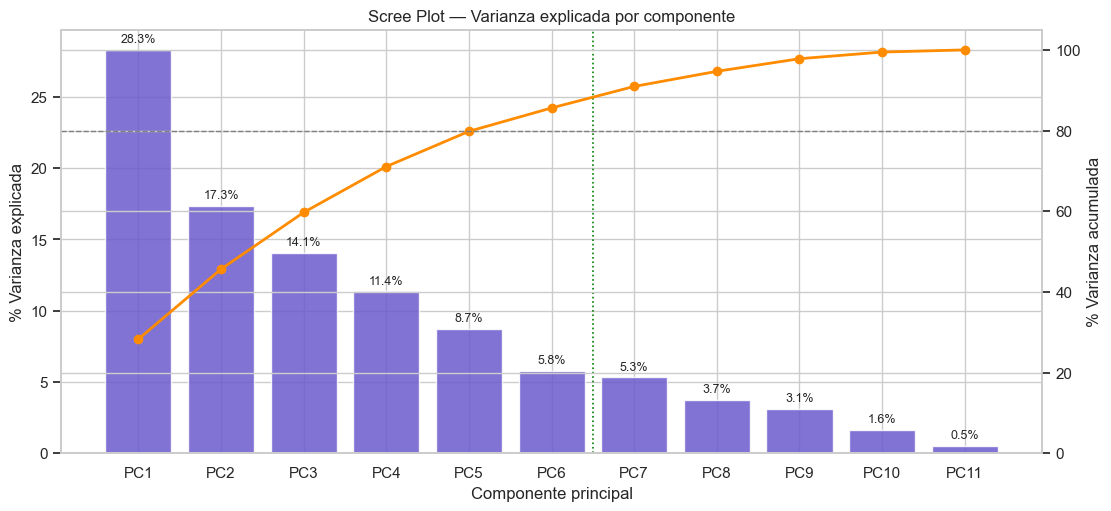

In [182]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
pca_wine.scree_plot(ax=ax)
plt.show()

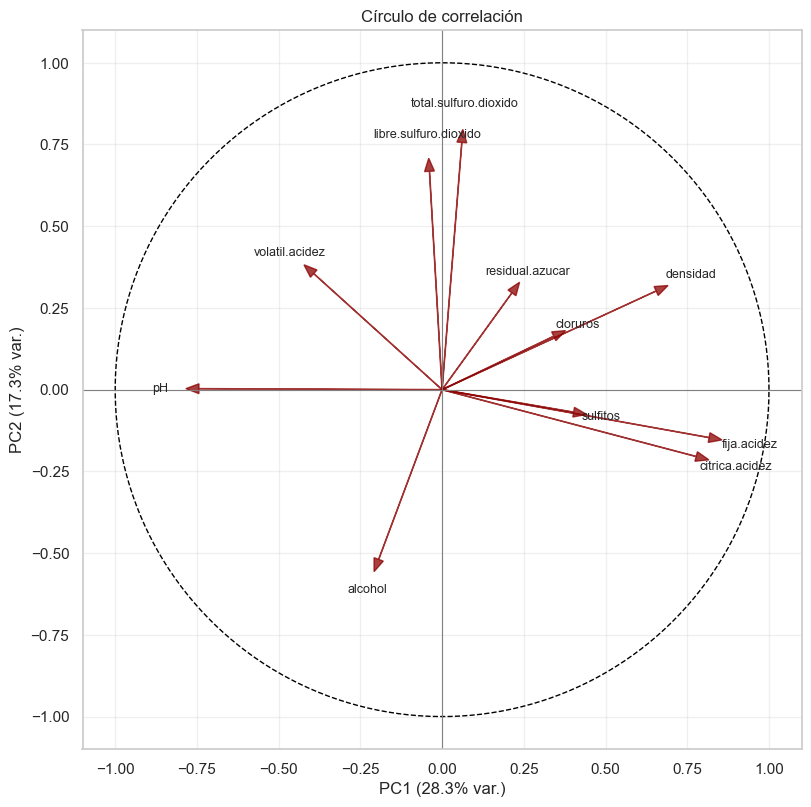

In [183]:
# Círculo de correlación: qué variables construyen los dos primeros ejes
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
pca_wine.circulo_correlacion(ejes=(1, 2), ax=ax)
plt.show()

In [184]:
# Contribución de cada variable a los primeros 4 componentes (en%)
pca_wine.contribuciones().iloc[:, :4]

,PC1,PC2,PC3,PC4
variable,,,,
fija.acidez,23.55,1.24,1.65,5.55
volatil.acidez,5.73,7.64,19.70,0.53
citrica.acidez,21.39,2.41,5.60,0.56
residual.azucar,1.81,5.66,1.31,16.42
cloruros,4.59,1.71,0.85,42.75
libre.sulfuro.dioxido,0.05,26.26,19.08,0.05
total.sulfuro.dioxido,0.13,33.22,10.71,0.08
densidad,15.35,5.32,12.23,3.23
pH,19.74,0.00,0.30,0.00


In [185]:
# Calidad de representación (cos²) de cada variable en los 4 componentes retenidos
cos2 = pca_wine.cos2_variables().iloc[:, :4]
cos2['cos2_acumulado'] = cos2.sum(axis=1)
cos2.round(3).sort_values('cos2_acumulado', ascending=False)

,PC1,PC2,PC3,PC4,cos2_acumulado
variable,,,,,
fija.acidez,0.733,0.024,0.026,0.070,0.852
densidad,0.478,0.102,0.189,0.040,0.809
citrica.acidez,0.666,0.046,0.087,0.007,0.806
total.sulfuro.dioxido,0.004,0.634,0.166,0.001,0.805
libre.sulfuro.dioxido,0.002,0.501,0.295,0.001,0.799
cloruros,0.143,0.033,0.013,0.535,0.723
alcohol,0.043,0.310,0.335,0.020,0.709
sulfitos,0.195,0.006,0.107,0.365,0.673
volatil.acidez,0.178,0.146,0.305,0.007,0.636


### Interpretación

La varianza está bastante repartida, señal de que las 11 variables no son tan redundantes como en otros datasets: **PC1 explica 28.3%**, PC2 17.4%, PC3 14.1% y PC4 11.4%. Con dos componentes solo se llega al **45.6%**, con cuatro al **71.1%** y hacen falta seis para pasar el 80%.

Por las contribuciones y el círculo de correlación, los ejes tienen una lectura química clara:

- **PC1 (28.3%)** — eje de **acidez y cuerpo**: acidez fija (23.6%), acidez cítrica (21.4%), pH (19.7%, en dirección opuesta) y densidad (15.4%). Separa vinos ácidos y densos de vinos de pH alto.
- **PC2 (17.4%)** — eje de **sulfitado**: dióxido de azufre total (33.2%) y libre (26.3%), con el alcohol (16.2%) apuntando al lado contrario. Separa vinos muy sulfitados y de bajo alcohol.
- **PC3 (14.1%)** — acidez volátil (19.7%) y alcohol (21.7%).
- **PC4 (11.4%)** — cloruros (42.8%) y sulfitos (29.2%): el eje de la **salinidad**.

Que dos componentes solo alcancen el 46% ya avisa que el mapa 2D va a ser una aproximación pobre del espacio real, y hay que tenerlo presente al mirar los gráficos de clusters más adelante.

La tabla de **cos²** dice qué tan bien queda representada cada variable en esos 4 ejes, con el umbral práctico del **60%** visto en clase. Diez de las once lo superan —la acidez fija llega a 0.85 y la densidad a 0.81—, así que sobre ellas se puede interpretar con confianza. La excepción es el **azúcar residual (0.39)**: se pierde en la reducción, y cualquier afirmación sobre esa variable a partir del plano hay que tomarla con pinzas.

## f) Cantidad de componentes a conservar

In [186]:
N_COMP = int((pca_wine.eigenvalues > 1).sum())

print(f'Componentes con eigenvalor > 1 (criterio de Kaiser): {N_COMP}')
print(f'Varianza acumulada con {N_COMP} componentes: {pca_wine.varianza_acumulada[N_COMP-1]:.1f}%')
print(f'Componentes necesarias para superar el 80%: {pca_wine.n_componentes_80()}')

coords_wine = pca_wine.row_coords.iloc[:, :N_COMP]
Z_wine = coords_wine.values
print(f'\nMatriz para el clustering: {Z_wine.shape[0]} vinos × {Z_wine.shape[1]} componentes')

Componentes con eigenvalor > 1 (criterio de Kaiser): 4
Varianza acumulada con 4 componentes: 71.1%
Componentes necesarias para superar el 80%: 6

Matriz para el clustering: 1359 vinos × 4 componentes


### Interpretación

Se conservan **4 componentes**, con **71.1% de la información** original. La decisión se apoya en dos criterios que coinciden:

- **Criterio de Kaiser:** exactamente 4 componentes tienen eigenvalor mayor a 1 (3.11, 1.91, 1.55 y 1.25). La quinta cae a 0.96, o sea que ya aportaría menos información que una variable original suelta, y no tiene sentido conservarla.
- **Varianza acumulada:** el 71% es un nivel razonable para pasar de 11 dimensiones a 4. Llegar al 80% exigiría 6 componentes, y la ganancia (9 puntos más) no compensa quedarse con casi la mitad de las dimensiones originales.

Estas 4 componentes son la entrada del clustering. La ventaja es doble: se le quita al algoritmo la multicolinealidad entre variables (que en una distancia euclidiana hace que la misma información se cuente varias veces) y se trabaja en un espacio más limpio, sin perder casi un tercio de la varianza.

## g) y h) K-Means sobre las componentes y elección de k con dos criterios

Se elige **K-Means** porque el objetivo es una segmentación en la que **todos los vinos queden asignados** a algún grupo, que es lo que se necesita para caracterizar perfiles. DBSCAN dejaría fuera como ruido a los vinos atípicos, y el clustering jerárquico es menos práctico con 1 359 observaciones.

Para el número de clusters se usan **dos criterios**: el codo de Jambú y el índice de silueta.

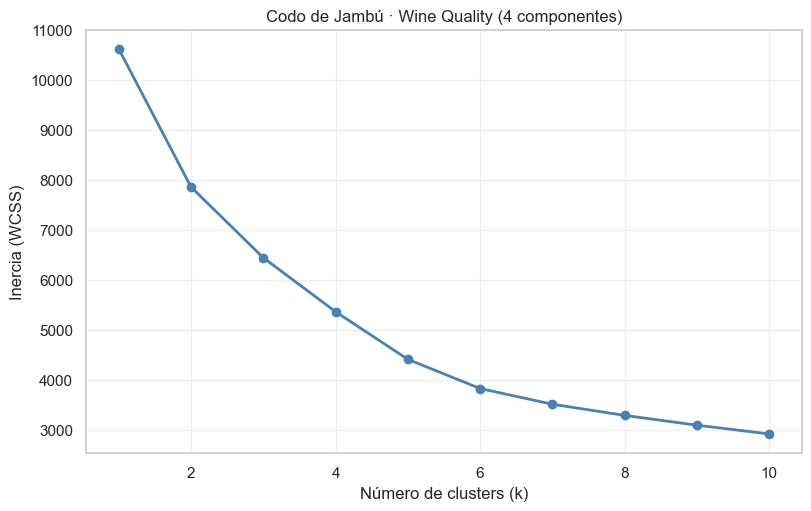

,k,inercia,reduccion_%
0,1,10625.2,NaN
1,2,7865.2,26.0
2,3,6450.3,18.0
3,4,5371.3,16.7
4,5,4418.6,17.7
5,6,3834.8,13.2
6,7,3520.0,8.2
7,8,3297.2,6.3
8,9,3087.7,6.4
9,10,2926.6,5.2


In [187]:
# Criterio 1: codo de Jambú
fig = codo_jambu(Z_wine, max_k=10)
plt.title('Codo de Jambú · Wine Quality (4 componentes)')
plt.show()

# Inercia y cuánto baja al agregar cada cluster
inercias = [KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(Z_wine).inertia_ for k in range(1, 11)]
tabla_codo = pd.DataFrame({'k': range(1, 11), 'inercia': np.round(inercias, 1)})
tabla_codo['reduccion_%'] = (-tabla_codo['inercia'].pct_change() * 100).round(1)
tabla_codo

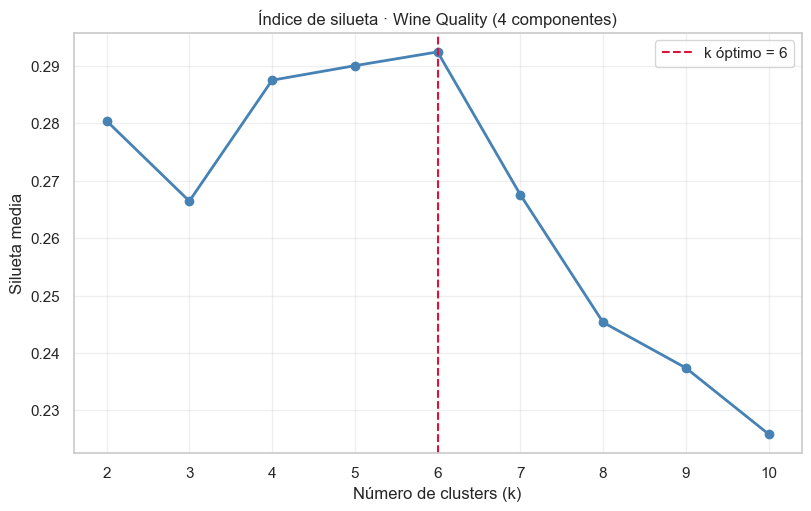

k con la silueta más alta: 6
  k = 2  →  silueta = 0.2804
  k = 3  →  silueta = 0.2664
  k = 4  →  silueta = 0.2892
  k = 5  →  silueta = 0.2900
  k = 6  →  silueta = 0.2924
  k = 7  →  silueta = 0.2675


In [188]:
# Criterio 2: índice de silueta
fig, K_SIL = silhouette_kmeans(Z_wine, max_k=10)
plt.title('Índice de silueta · Wine Quality (4 componentes)')
plt.show()

print(f'k con la silueta más alta: {K_SIL}')
for k in range(2, 8):
    etq = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit_predict(Z_wine)
    print(f'  k = {k}  →  silueta = {silhouette_score(Z_wine, etq):.4f}')

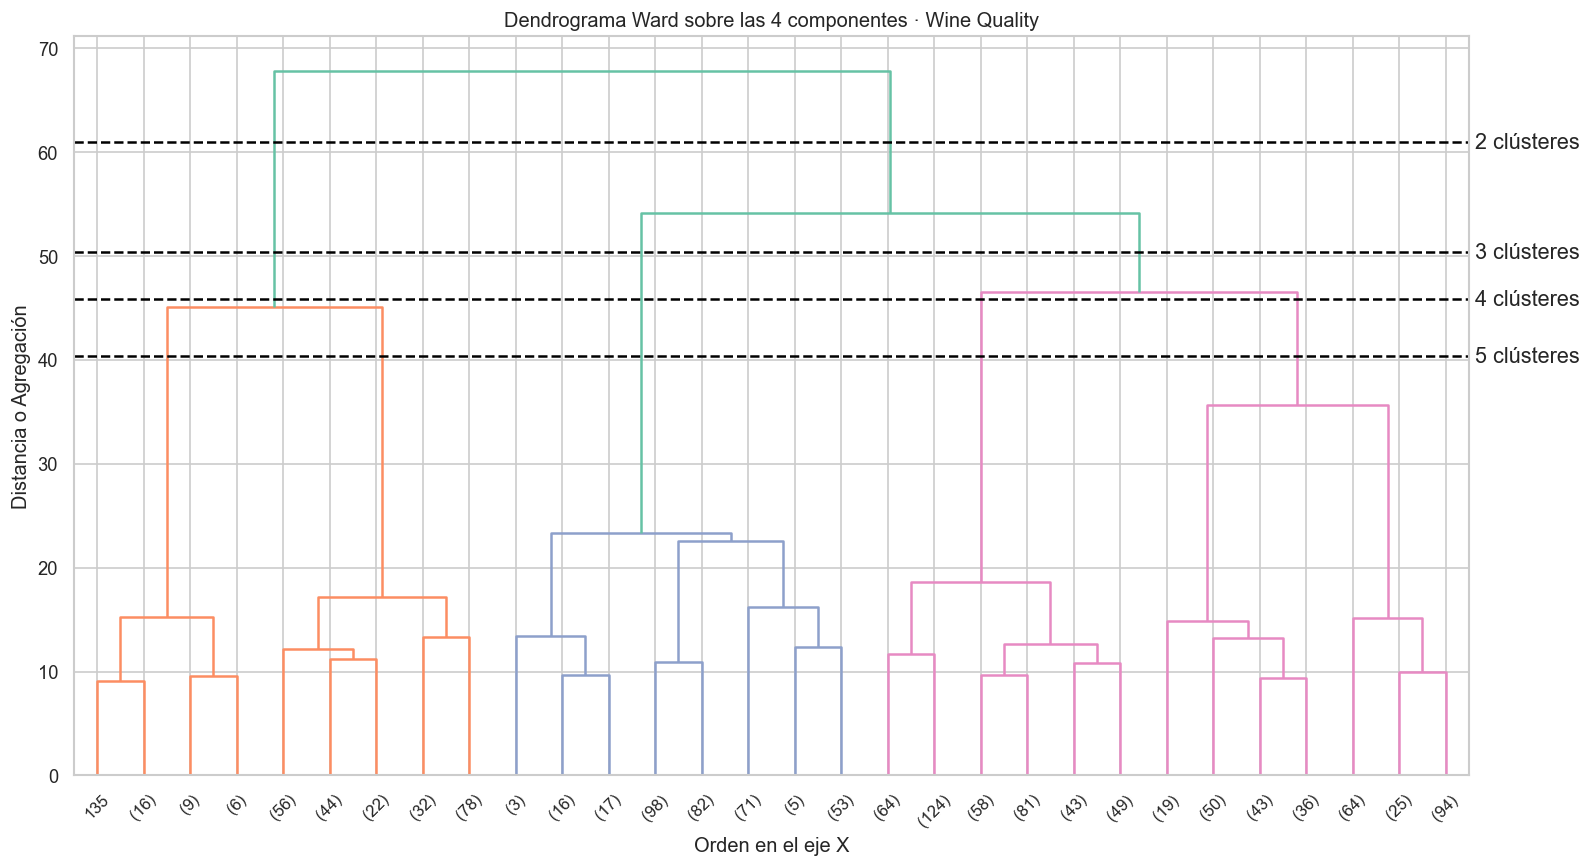

In [189]:
# Criterio 3: dendrograma de Ward sobre las mismas 4 componentes
ward_res, average_res, single_res, complete_res = agregaciones(Z_wine)

fig = plot_dendrograma_cortes(
    ward_res,
    cortes=[(altura_corte(ward_res, k), f'{k} clústeres') for k in (2, 3, 4, 5)],
    titulo='Dendrograma Ward sobre las 4 componentes · Wine Quality',
    truncate_mode='lastp',
    p=30,
)
plt.show()

In [190]:
# Un corte es estable cuando la ventana de altura entre dos fusiones consecutivas es ancha:
# si la ventana es angosta, ese número de clusters "dura" muy poco en el árbol.
alturas = np.sort(ward_res[:, 2])[-6:][::-1]

print('Altura de las últimas fusiones del dendrograma Ward:')
for i, h in enumerate(alturas):
    print(f'  la fusión que deja {i+1} grupo(s) ocurre a la altura {h:.1f}')

print('\nVentana de altura en la que se mantiene cada solución:')
for k in range(2, 6):
    print(f'  {k} grupos: {alturas[k-2] - alturas[k-1]:.1f}')

Altura de las últimas fusiones del dendrograma Ward:
  la fusión que deja 1 grupo(s) ocurre a la altura 67.7
  la fusión que deja 2 grupo(s) ocurre a la altura 54.1
  la fusión que deja 3 grupo(s) ocurre a la altura 46.6
  la fusión que deja 4 grupo(s) ocurre a la altura 45.1
  la fusión que deja 5 grupo(s) ocurre a la altura 35.7
  la fusión que deja 6 grupo(s) ocurre a la altura 23.3

Ventana de altura en la que se mantiene cada solución:
  2 grupos: 13.6
  3 grupos: 7.6
  4 grupos: 1.5
  5 grupos: 9.4


### Interpretación

El **codo de Jambú** marca el quiebre aproximadamente en **k = 5**: la inercia baja 26% al pasar de 1 a 2 clusters, 18% de 2 a 3, 17% de 3 a 4 y 18% de 4 a 5, pero de 5 a 6 la caída ya es de solo 13% y sigue achicándose. Después de 5 la curva se aplana.

El **índice de silueta** es prácticamente plano entre k = 4 y k = 6 (0.289, 0.290 y 0.292): su máximo está en 6, pero una diferencia de dos milésimas no es evidencia de nada. Lo que sí hace es descartar k = 3 (0.266) y k = 7 (0.267).

El **dendrograma de Ward** aporta el criterio que desempata. Mirando la altura a la que ocurre cada fusión, se puede medir la altura de cada árbol: la ventana de altura es de 13.6 para 2 grupos, 7.6 para 3, apenas **1.5 para 4** y **9.4 para 5**. Que la ventana de 4 grupos sea tan angosta significa que ese corte es inestable —basta mover un poco la línea para pasar a 3 o a 5—, mientras el de 5 grupos se mantiene en un rango ancho de alturas.

Con los tres criterios apuntando en la misma dirección —el codo lo señala, la silueta lo ubica en su zona alta y el dendrograma lo muestra como corte estable— se trabaja con **k = 5**. Vale decir de una vez que un valor de silueta de 0.29 está **por debajo del umbral de 0.4** visto en clase: los grupos existen pero no están nítidamente separados, y eso hay que arrastrarlo hasta la conclusión.

Dicho sea de paso, esa silueta baja está funcionando como el diagnóstico de **clusterabilidad** del que se habla en la pregunta 15 de la Parte I: un dataset con grupos bien definidos no se comporta así. Un chequeo formal previo con el estadístico de **Hopkins** o el **VAT** nos ayudaría tambien a anticipar este resultado antes de correr el algoritmo.

In [191]:
K_OPT = 5

kmedias = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=20)
etiquetas = kmedias.fit_predict(Z_wine)
wine_mod['cluster'] = etiquetas

sil_media = silhouette_score(Z_wine, etiquetas)
print(f'K-Means con k = {K_OPT}   |   silueta media = {sil_media:.4f}')
print('\nTamaño de cada cluster:')
print(pd.Series(etiquetas).value_counts().sort_index())

K-Means con k = 5   |   silueta media = 0.2900

Tamaño de cada cluster:
0    311
1     29
2    278
3    267
4    474
Name: count, dtype: int64


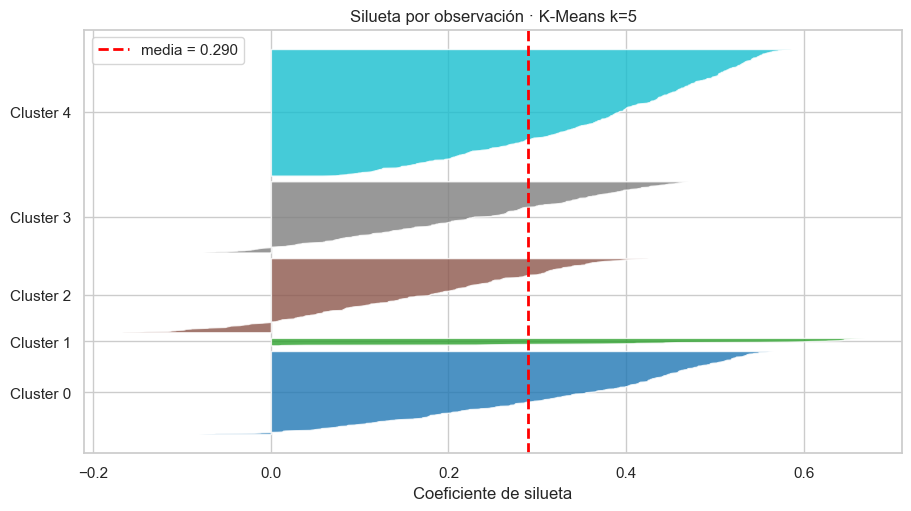

Silueta media por cluster:
0    0.323
1    0.474
2    0.161
3    0.223
4    0.371
dtype: float64


In [192]:
# Gráfico de silueta
sil_vals = silhouette_samples(Z_wine, etiquetas)
clusters = sorted(np.unique(etiquetas))
colores = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
y = 0
yticks = []
for i, c in enumerate(clusters):
    vals = np.sort(sil_vals[etiquetas == c])
    ax.fill_betweenx(range(y, y + len(vals)), 0, vals, facecolor=colores[i], alpha=0.8)
    yticks.append(y + len(vals) / 2)
    y += len(vals) + 20

ax.axvline(sil_media, color='red', linestyle='--', linewidth=2, label=f'media = {sil_media:.3f}')
ax.set_yticks(yticks)
ax.set_yticklabels([f'Cluster {c}' for c in clusters])
ax.set_xlabel('Coeficiente de silueta')
ax.set_title(f'Silueta por observación · K-Means k={K_OPT}')
ax.legend()
plt.show()

print('Silueta media por cluster:')
print(pd.Series(sil_vals).groupby(etiquetas).mean().round(3))

## i) Visualización de los clusters sobre los componentes principales

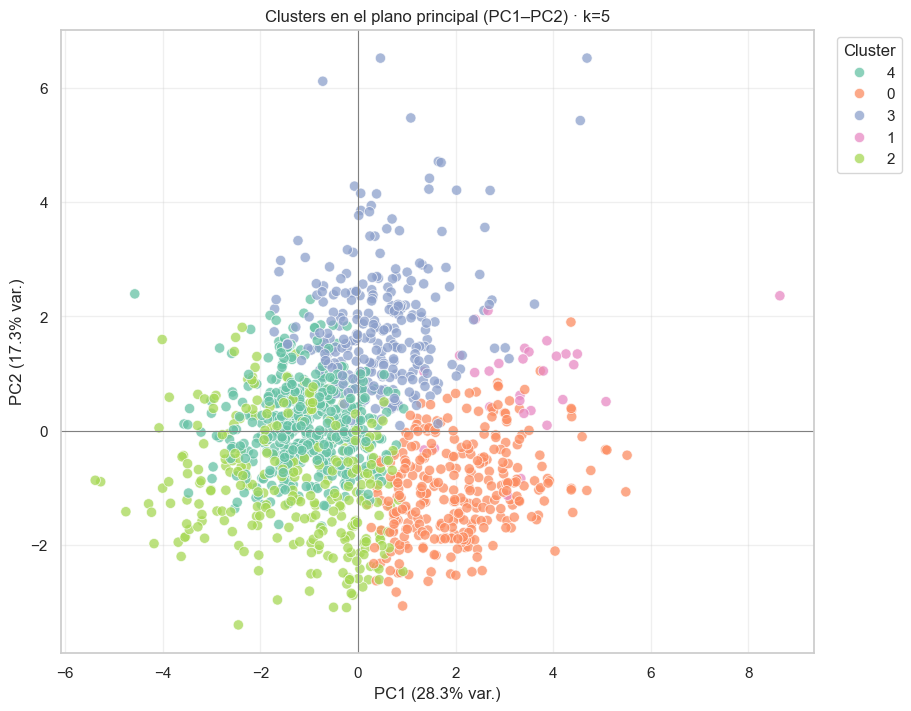

In [193]:
hue_cluster = pd.Series(etiquetas, name='Cluster').astype(str)

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
pca_wine.plano_principal(hue=hue_cluster, ejes=(1, 2), ax=ax)
ax.set_title(f'Clusters en el plano principal (PC1–PC2) · k={K_OPT}')
plt.show()

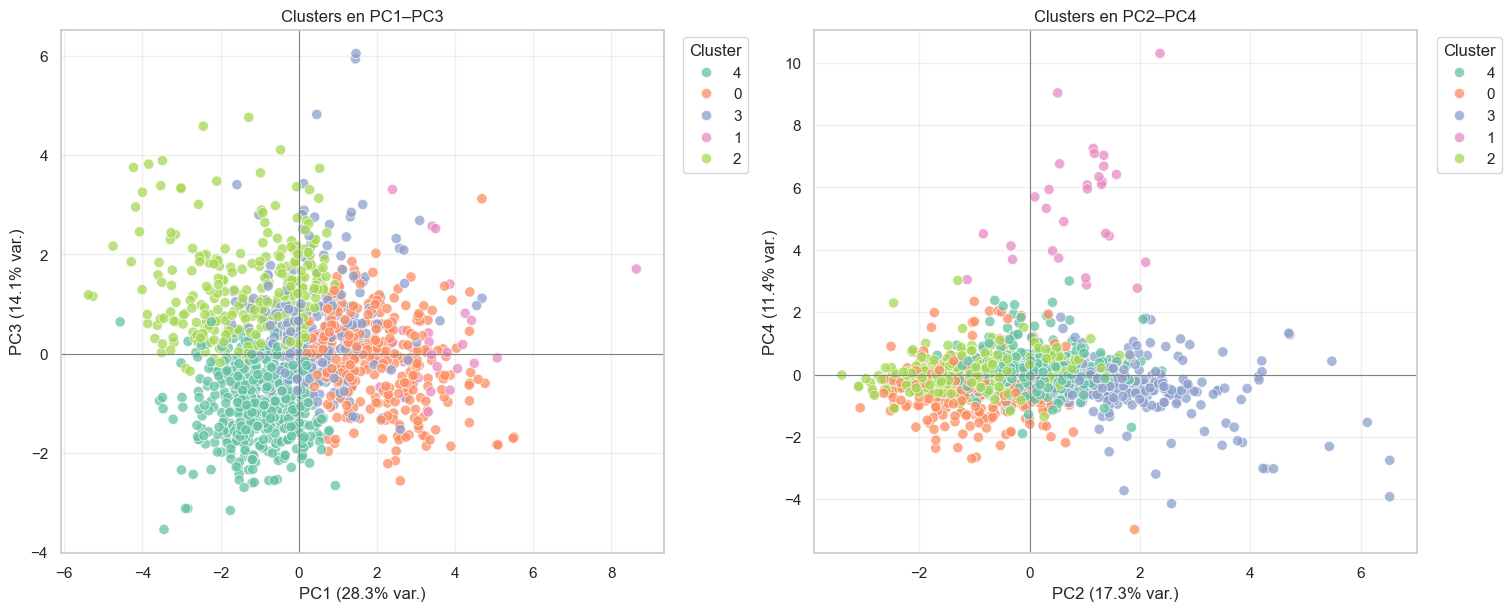

In [194]:
# Los ejes 1-2 solo cubren el 45.7% de la varianza: se revisan también PC3 y PC4
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
pca_wine.plano_principal(hue=hue_cluster, ejes=(1, 3), ax=axes[0])
axes[0].set_title('Clusters en PC1–PC3')
pca_wine.plano_principal(hue=hue_cluster, ejes=(2, 4), ax=axes[1])
axes[1].set_title('Clusters en PC2–PC4')
plt.show()

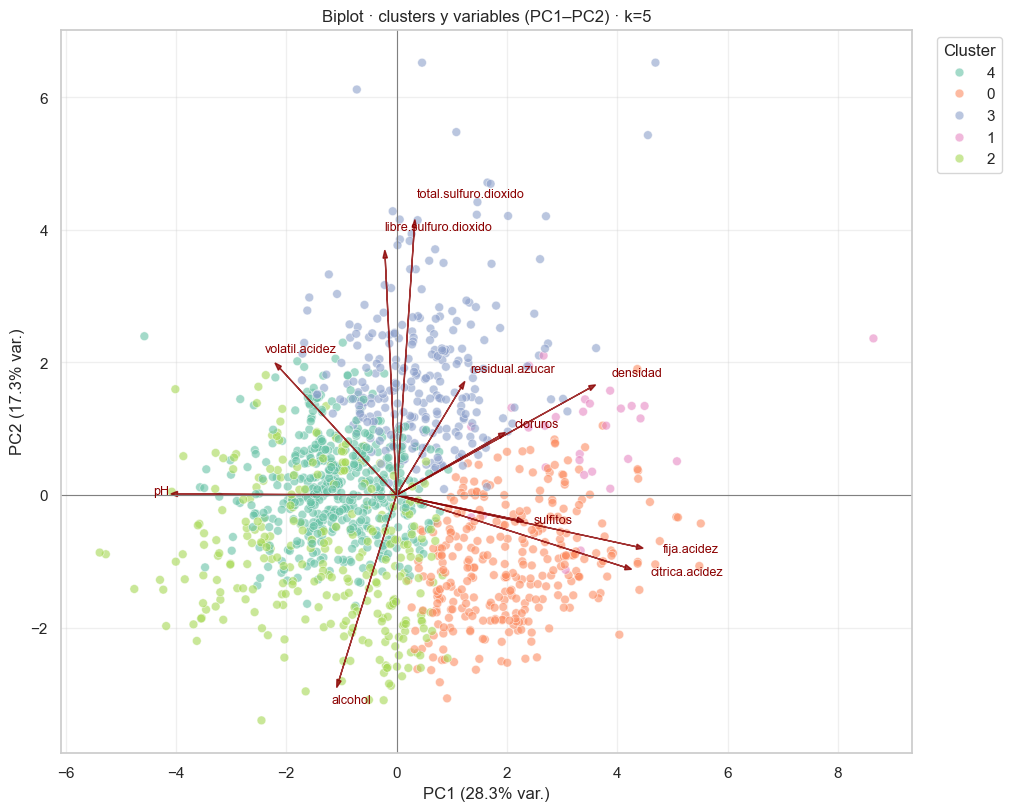

In [195]:
# Biplot: clusters + variables sobre el mismo plano
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
pca_wine.biplot(hue=hue_cluster, ejes=(1, 2), ax=ax)
ax.set_title(f'Biplot · clusters y variables (PC1–PC2) · k={K_OPT}')
plt.show()

In [196]:
# Posición promedio de cada cluster en cada componente: confirma qué eje separa a cuáles
print('Coordenada media de cada cluster en las 4 componentes:')
print(coords_wine.groupby(etiquetas).mean().round(2))

Coordenada media de cada cluster en las 4 componentes:
    PC1   PC2   PC3   PC4
0  2.05 -1.00 -0.12 -0.45
1  3.42  0.85  0.27  5.43
2 -1.32 -0.94  1.30  0.11
3  0.46  1.85  0.54 -0.37
4 -1.04  0.12 -1.01  0.11


### Interpretación

En el plano PC1–PC2 los clusters se ordenan de forma coherente pero **con fronteras que se tocan**: no hay nubes despegadas, sino una nube continua repartida en zonas. Eso es exactamente lo que anticipaba la silueta de 0.29.

Aun así el reparto tiene sentido y se lee bien en el biplot:

- El **cluster 0** se va hacia la derecha, en la dirección de la acidez fija y la acidez cítrica.
- El **cluster 3** se va hacia arriba, siguiendo las flechas del dióxido de azufre total y libre.
- El **cluster 2** se ubica del lado opuesto al azufre, donde apunta el alcohol.
- El **cluster 4** queda en la zona de la acidez volátil y pH alto.
- El **cluster 1**, el más pequeño, se separa mucho mejor en el plano **PC2–PC4** que en PC1–PC2, porque su rasgo distintivo son los cloruros y los sulfitos, que es lo que construye PC4.

Este último punto es el mejor recordatorio de la advertencia vista en clase: un cluster puede verse mal separado en un plano no porque el algoritmo se equivocara, sino porque **el plano elegido no contiene la información que lo distingue**.

La tabla de coordenadas medias lo confirma con números y deja ver algo mejor todavía: **cada componente retenida se encarga de aislar a un grupo distinto**. El cluster 0 se define por PC1 (2.05), el 3 por PC2 (1.85), el 1 por PC4 (5.43) y el 2 por PC3 (1.30). Esa es la mejor justificación de haber conservado 4 componentes y no 2: si se hubieran usado solo las dos primeras, los clusters 1 y 2 no habrían tenido eje propio donde separarse.

También explica las siluetas por cluster. El 1 es el mejor formado (0.474) porque su PC4 lo deja lejos de todo; el 2 es el más débil (0.161) porque comparte la mitad izquierda del plano principal con el 4 (PC1 −1.32 contra −1.04, PC2 −0.94 contra 0.12) y solo se distinguen en PC3, un eje que el gráfico PC1–PC2 no muestra.

## j) Interpretación de los clusters con las variables originales

In [197]:
# Centroides en la escala original: promedio de cada variable dentro de cada cluster
centros_wine = wine_mod.groupby('cluster')[FEATURES].mean()
centros_wine.round(2).T

cluster,0,1,2,3,4
fija.acidez,10.61,8.37,7.08,8.34,7.50
volatil.acidez,0.40,0.51,0.45,0.54,0.65
citrica.acidez,0.49,0.49,0.24,0.30,0.12
residual.azucar,2.71,1.98,2.17,3.22,2.25
cloruros,0.09,0.34,0.07,0.09,0.08
libre.sulfuro.dioxido,10.21,15.62,17.35,28.06,11.93
total.sulfuro.dioxido,28.75,62.52,40.56,92.54,35.65
densidad,1.00,1.00,0.99,1.00,1.00
pH,3.18,3.05,3.41,3.28,3.37
sulfitos,0.72,1.26,0.68,0.63,0.59


In [198]:
# El mismo perfil pero en desviaciones estándar respecto al promedio general: permite ver de un golpe qué tan lejos del vino promedio está cada grupo en cada variable
perfil_z = (centros_wine - wine_mod[FEATURES].mean()) / wine_mod[FEATURES].std()
perfil_z.round(2).T

cluster,0,1,2,3,4
fija.acidez,1.32,0.04,-0.71,0.02,-0.47
volatil.acidez,-0.68,-0.08,-0.44,0.06,0.68
citrica.acidez,1.11,1.09,-0.16,0.16,-0.79
residual.azucar,0.14,-0.40,-0.26,0.52,-0.21
cloruros,-0.03,5.16,-0.40,0.02,-0.07
libre.sulfuro.dioxido,-0.54,-0.03,0.14,1.16,-0.38
total.sulfuro.dioxido,-0.54,0.47,-0.19,1.37,-0.33
densidad,0.73,0.21,-1.21,0.46,-0.04
pH,-0.85,-1.64,0.64,-0.21,0.40
sulfitos,0.36,3.55,0.10,-0.17,-0.41


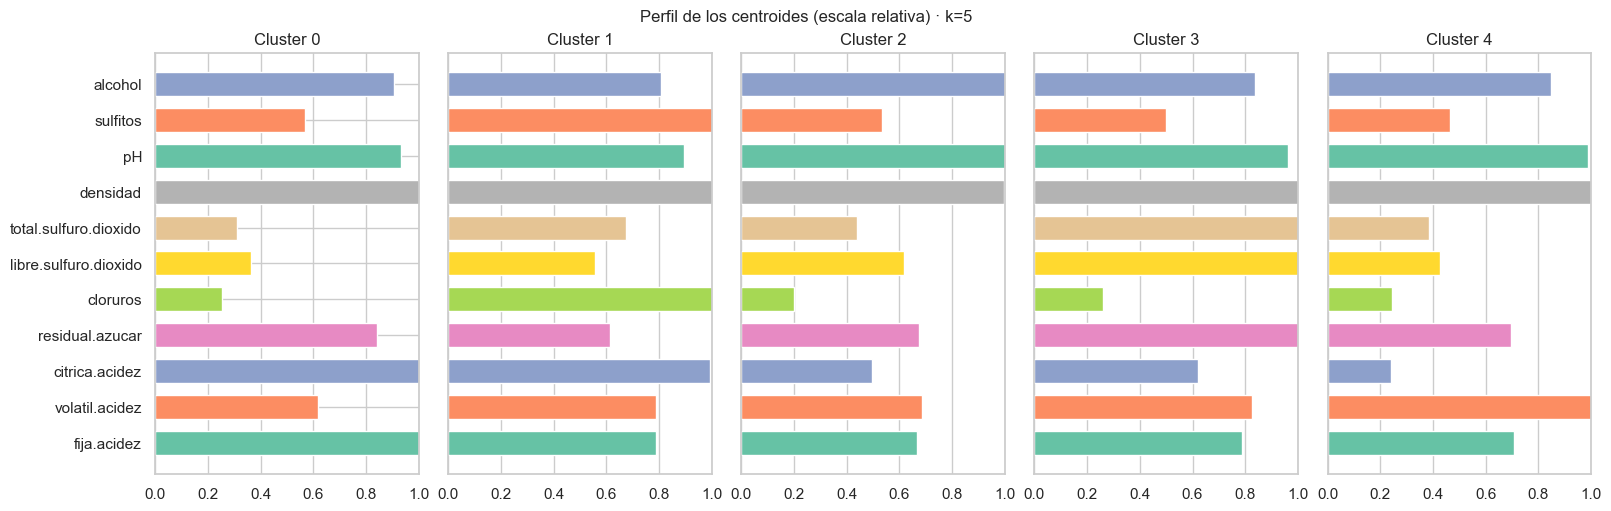

In [199]:
fig = bar_plot(centros_wine.values, list(FEATURES), scale=True, figsize=(16, 5))
plt.suptitle(f'Perfil de los centroides (escala relativa) · k={K_OPT}', fontsize=12)
plt.show()

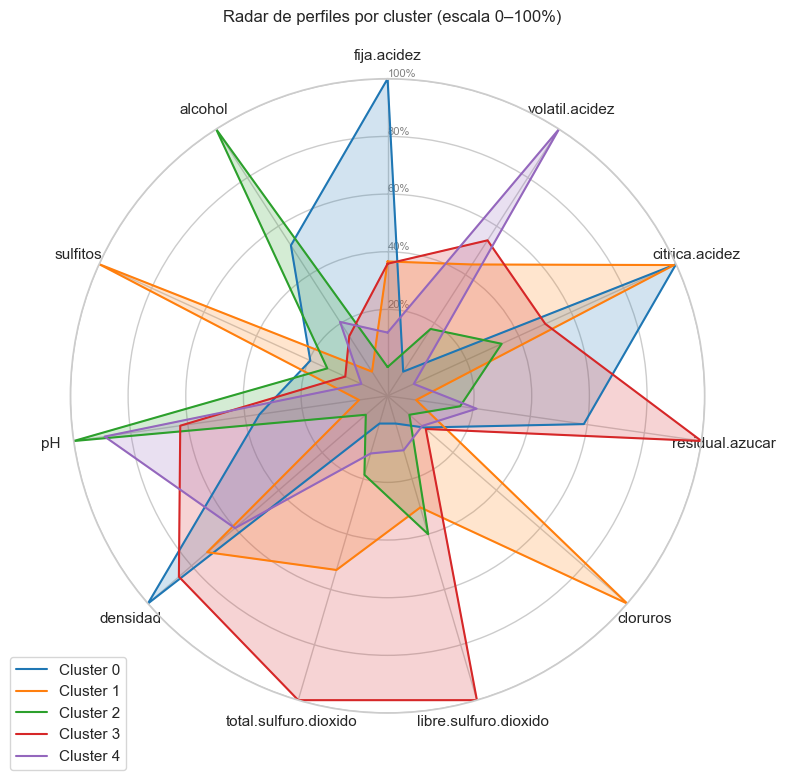

In [200]:
fig = radar_plot(centros_wine.values, list(FEATURES))
plt.show()

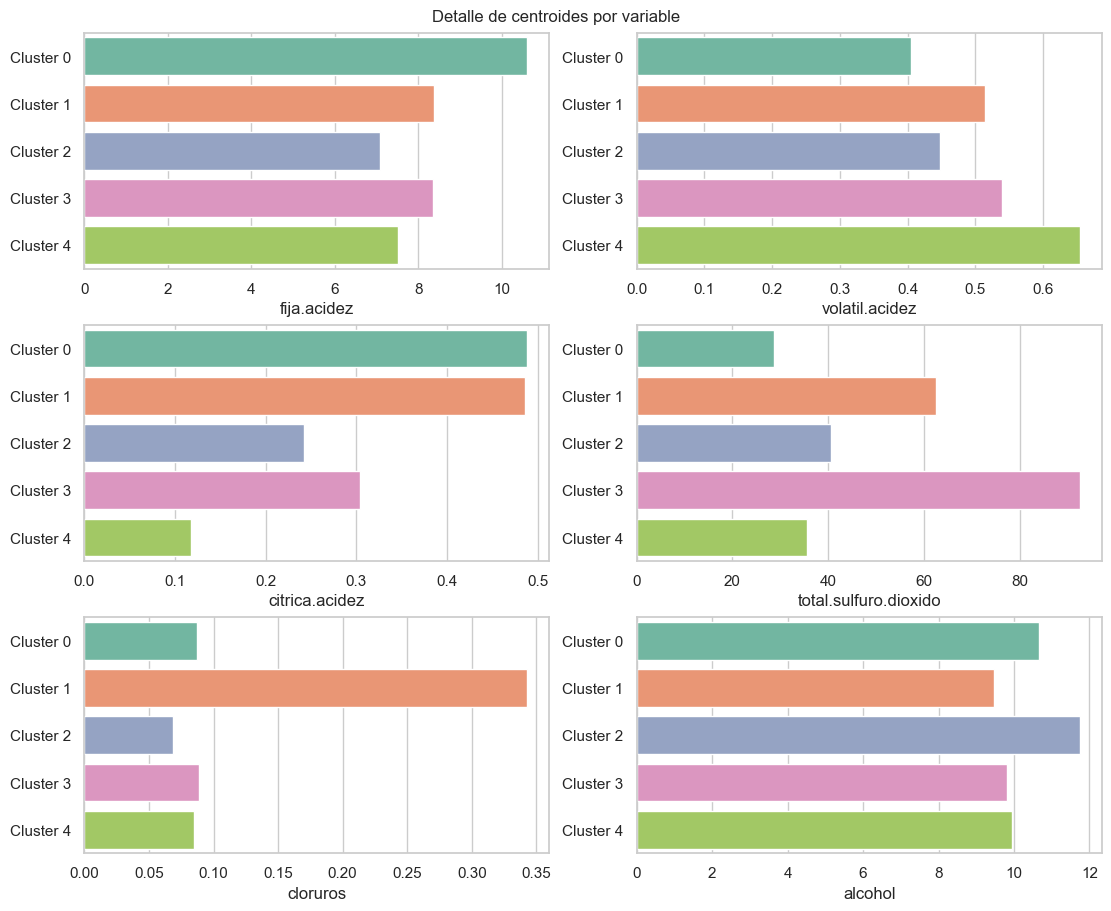

In [201]:
# Variables que más diferencian los grupos: detalle por variable
fig = bar_plot_detail(centros_wine.values, list(FEATURES),
                      columns_to_plot=['fija.acidez', 'volatil.acidez', 'citrica.acidez',
                                       'total.sulfuro.dioxido', 'cloruros', 'alcohol'],
                      figsize=(11, 9))
plt.show()

In [202]:
# Validación externa: la calidad no entró al modelo, se usa solo para leer el resultado
print('Calidad media por cluster:')
print(wine_mod.groupby('cluster')['calidad'].agg(['mean', 'count']).round(2))

print('\nTabla cruzada cluster × calidad:')
print(pd.crosstab(wine_mod['cluster'], wine_mod['calidad']))

Calidad media por cluster:
         mean  count
cluster             
0        5.96    311
1        5.31     29
2        6.13    278
3        5.31    267
4        5.30    474

Tabla cruzada cluster × calidad:
calidad  3   4    5    6   7   8
cluster                         
0        2   5   77  151  70   6
1        0   1   19    8   1   0
2        0   4   46  148  70  10
3        1   5  182   68  10   1
4        7  38  253  160  16   0


### Interpretación

Los cinco grupos tienen un perfil químico propio y distinguible:

| Cluster | n | Rasgos que lo definen | Calidad media |
|---|---:|---|---:|
| **0** | 311 | Acidez fija (10.6) y cítrica (0.49) altas, pH bajo (3.18), poco azufre | 5.96 |
| **1** | 29 | **Cloruros 0.34 y sulfitos 1.26** — casi 4 y 2 veces el resto; vinos salinos | 5.31 |
| **2** | 278 | **Alcohol 11.7** (el más alto), densidad más baja, acidez volátil moderada | 6.13 |
| **3** | 267 | **Azufre total 92.5 y libre 28** (el doble del resto), azúcar residual 3.22 (el más alto), alcohol bajo (9.8) | 5.31 |
| **4** | 474 | **Acidez volátil 0.65** (la más alta), acidez cítrica 0.12 (la más baja), alcohol 9.9 | 5.30 |

Lo que separa a los grupos es entonces **el estilo de vinificación**, no la calidad: acidez y cuerpo (cluster 0), grado alcohólico (2), nivel de sulfitado (3), acidez volátil (4) y salinidad (1).

El perfil en desviaciones estándar pone en escala esas diferencias. Las más marcadas son las del **cluster 1: cloruros a 5.16 desviaciones** del vino promedio y sulfitos a 3.55 — una distancia enorme, que confirma que ese grupo son los vinos atípicos que se decidió conservar en el inciso c). Los demás se mueven en un rango mucho más moderado (entre 0.5 y 1.4 desviaciones), lo que vuelve a decir lo mismo que la silueta: son variaciones de estilo dentro de una misma población, no poblaciones aparte. Sobre el azúcar residual del cluster 3 conviene no insistir demasiado: su cos² era de 0.39, o sea que es la variable peor representada en estos ejes.

El cruce con la calidad (que nunca entró al modelo) muestra un patrón interesante aunque suave. El cluster 2, el de alcohol alto, tiene la mejor calidad media (**6.13**) y el 0 le sigue (5.96); mientras el 4, con la acidez volátil más alta, se queda en **5.30**. Basado en una pequeña investigación de como funciona el proceso de crear vinos (enología), todo esto tiene sentido: la acidez volátil en exceso es un defecto (avinagra el vino) y el grado alcohólico suele acompañar a vinos más maduros y estructurados. Pero es solo un gradiente de menos de un punto en una escala de 0 a 10, y ningún cluster es "el de los vinos buenos": todos mezclan notas 5, 6 y 7.

Este gradiente no sale de la nada: en la matriz de correlación del inciso a) el alcohol ya era la variable más asociada a la calidad (**0.48**) y la acidez volátil la más asociada en negativo (**−0.39**). O sea que el clustering reordenó a los vinos según ejes químicos que, sin buscarlo, arrastran algo de la señal de calidad — pero de forma indirecta y débil.

## k) Conclusión del Caso 1

**Sí hay estructura en los datos, pero es débil, y no es la estructura de la calidad.** Las 11 variables fisicoquímicas se pudieron resumir en 4 componentes que retienen el 71% de la información, y sobre ellas K-Means con k = 5 (respaldado por el codo de Jambú y el índice de silueta) produce cinco grupos con perfiles químicos claramente distinguibles: vinos ácidos y con cuerpo, vinos de alto grado alcohólico, vinos muy sulfitados, vinos con acidez volátil elevada y un grupo pequeño de vinos salinos.

Todo esto obliga a marcar el límite: la **silueta media es 0.29**, por debajo del umbral de 0.4 visto en clase, y en el plano principal las fronteras entre grupos se tocan. No son cinco poblaciones separadas sino zonas de una nube continua — algo esperable en un producto donde las variables cambian de forma gradual y no hay tres cultivares distintos detrás, como sí ocurría en el dataset Wine de la Tarea 6, donde la misma metodología dio una silueta mucho mejor y clusters despegados.

**¿Es una segmentación útil?** Como descripción de estilos de vino, sí: los perfiles son interpretables y accionables (un grupo con exceso de acidez volátil o de sulfitado es una señal concreta de proceso). Como herramienta para predecir o segmentar por calidad, no: la calidad media va de 5.30 a 6.13 y todos los grupos mezclan notas, así que quien quiera explicar la calidad debería ir a un modelo supervisado y no a un clustering. También conviene no tomarse los cinco grupos como fronteras rígidas: con una silueta así, muchos vinos quedan cerca del límite y su asignación podría cambiar con otra corrida o otro algoritmo.

---

# Caso 2. Descubrimiento de estructuras en el Iris Dataset

**Objetivo:** clusterizar Iris usando únicamente las cuatro variables predictoras y comparar después los grupos encontrados con las especies reales.

La variable `tipo` (la especie) **no se usa para construir los clusters**; se reserva para los incisos i) y j). Se trabaja con el archivo `datos/iris.csv`, que es el mismo Iris disponible en scikit-learn.

## a) Carga y exploración inicial

In [203]:
iris = pd.read_csv('datos/iris.csv', sep=';')

print(f'Observaciones: {iris.shape[0]}   |   Variables: {iris.shape[1]}')
print('\nColumnas:', list(iris.columns))
iris.head()

Observaciones: 150   |   Variables: 5

Columnas: ['s.largo', 's.ancho', 'p.largo', 'p.ancho', 'tipo']


,s.largo,s.ancho,p.largo,p.ancho,tipo
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [204]:
iris.info()

print('\nValores faltantes:', iris.isnull().sum().sum())
print(f'Filas duplicadas: {iris.duplicated().sum()}')
print('\nDistribución de la especie (solo para conocer el dataset, no entra al modelo):')
print(iris['tipo'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   s.largo  150 non-null    float64
 1   s.ancho  150 non-null    float64
 2   p.largo  150 non-null    float64
 3   p.ancho  150 non-null    float64
 4   tipo     150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Valores faltantes: 0
Filas duplicadas: 3

Distribución de la especie (solo para conocer el dataset, no entra al modelo):
tipo
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [205]:
VARS_IRIS = ['s.largo', 's.ancho', 'p.largo', 'p.ancho']
iris[VARS_IRIS].describe().round(2)

,s.largo,s.ancho,p.largo,p.ancho
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## b) Escalas y distribuciones

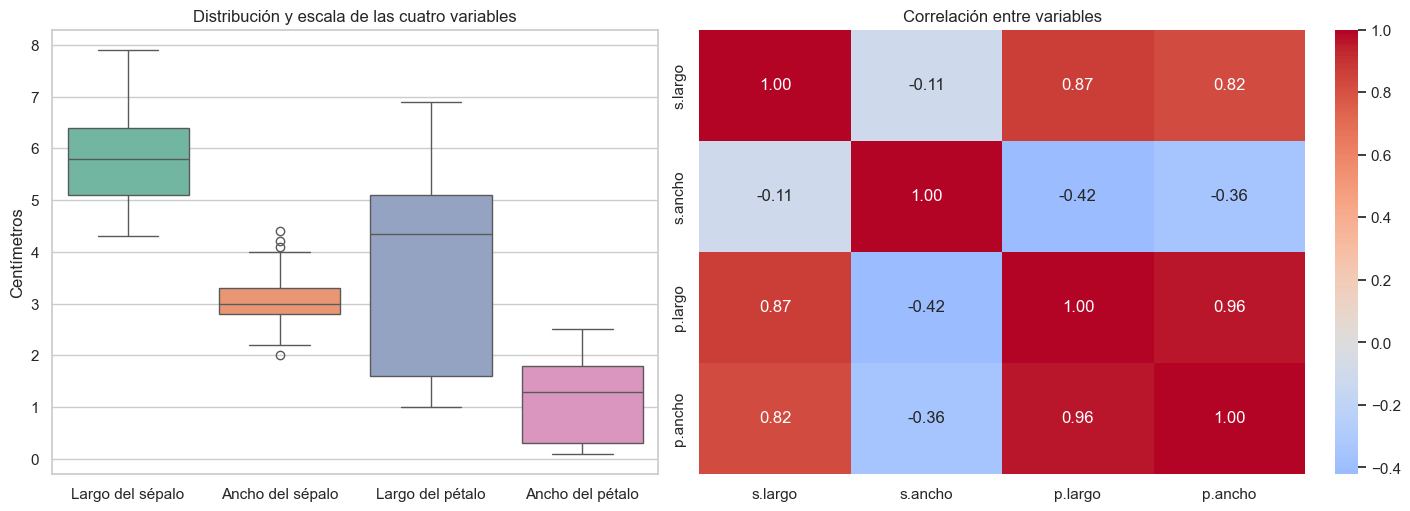

In [206]:
# Nombres legibles solo para los gráficos (las columnas del dataset no se tocan)
NOMBRES_IRIS = {
    's.largo': 'Largo del sépalo',
    's.ancho': 'Ancho del sépalo',
    'p.largo': 'Largo del pétalo',
    'p.ancho': 'Ancho del pétalo',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.boxplot(data=iris[VARS_IRIS].rename(columns=NOMBRES_IRIS), ax=axes[0])
axes[0].set_title('Distribución y escala de las cuatro variables')
axes[0].set_ylabel('Centímetros')

graficos_iris = GraficosCuantitativos(iris, cols=VARS_IRIS)
graficos_iris.heatmap_correlacion(ax=axes[1])
axes[1].set_title('Correlación entre variables')
plt.show()

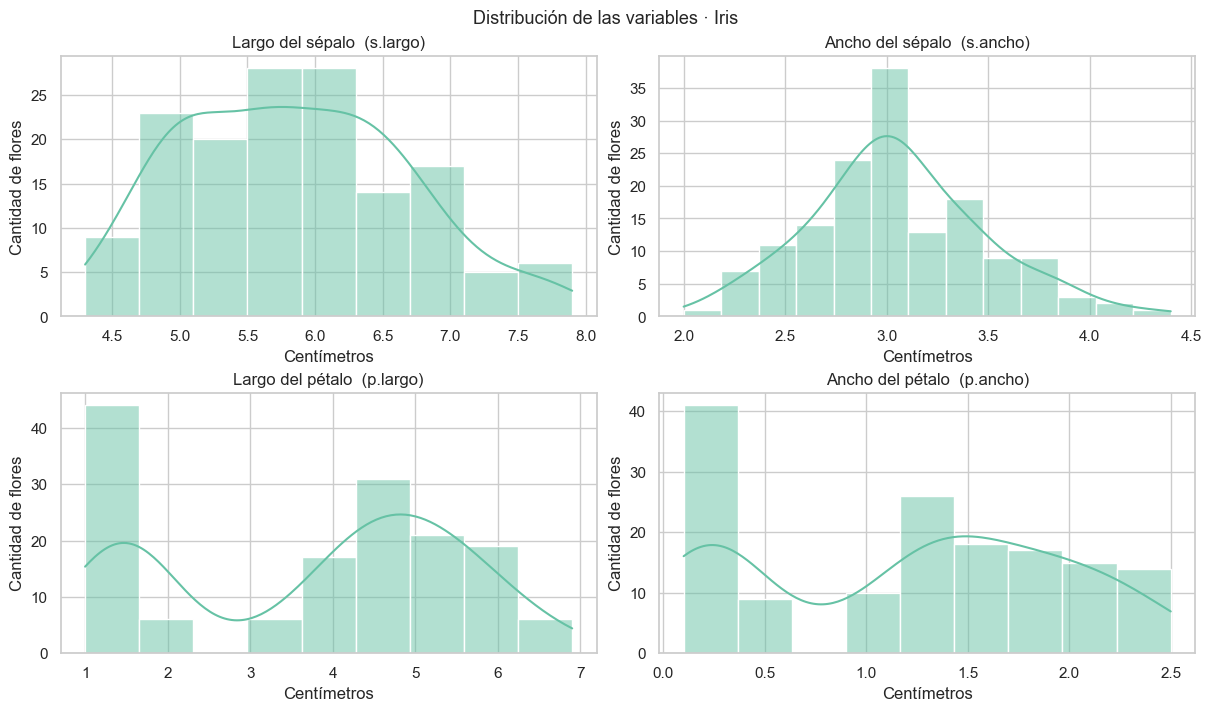

In [207]:
# Histogramas de cada variable: las barras cuentan flores, la línea es la densidad suavizada (KDE)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for ax, col in zip(axes.ravel(), VARS_IRIS):
    sns.histplot(iris[col], kde=True, ax=ax)
    ax.set_title(f'{NOMBRES_IRIS[col]}  ({col})')
    ax.set_xlabel('Centímetros')
    ax.set_ylabel('Cantidad de flores')
fig.suptitle('Distribución de las variables · Iris', fontsize=13)
plt.show()

In [208]:
# Comparación de escalas antes y después de estandarizar
X_iris = StandardScaler().fit_transform(iris[VARS_IRIS])

pd.DataFrame({
    'media': iris[VARS_IRIS].mean(),
    'desv': iris[VARS_IRIS].std(),
    'min': iris[VARS_IRIS].min(),
    'max': iris[VARS_IRIS].max(),
    'desv_estandarizada': X_iris.std(axis=0),
}).round(2)

,media,desv,min,max,desv_estandarizada
s.largo,5.84,0.83,4.3,7.9,1.0
s.ancho,3.05,0.43,2.0,4.4,1.0
p.largo,3.76,1.76,1.0,6.9,1.0
p.ancho,1.20,0.76,0.1,2.5,1.0


### Interpretación

Las cuatro variables están **en la misma unidad (centímetros)** y sin valores faltantes, así que el problema de escala es mucho más leve que en el caso del vino. Hay 3 filas duplicadas, pero aquí se conservan: con solo cuatro medidas redondeadas a un decimal es perfectamente normal que dos flores distintas coincidan, y quitarlas desbalancearía los 50 casos por especie. Aun así las variables no son equivalentes entre sí: el largo de pétalo tiene una desviación de 1.76 cm y un rango de 1 a 6.9, mientras el ancho de sépalo se mueve apenas entre 2 y 4.4 con desviación 0.43. Esa diferencia de cuatro veces en variabilidad bastaría para que el largo de pétalo dominara el PCA, así que **sí se estandariza**.

En los histogramas aparece algo revelador: el largo y el ancho de pétalo son claramente **bimodales** (un grupo pequeño bien separado y otro más grande) mientras las variables de sépalo son más unimodales. Eso ya adelanta que las medidas de pétalo son las que van a marcar los grupos. La correlación lo confirma: largo y ancho de pétalo están correlacionados en 0.96 entre sí, y con el largo de sépalo en 0.87 y 0.82 respectivamente, o sea que hay bastante redundancia para que el PCA aproveche.

No se aplica ninguna otra transformación: no hay asimetrías fuertes ni atípicos que lo justifiquen.

## c) y d) Reducción de dimensionalidad y dimensiones a conservar

Se usa **PCA**. La justificación: las cuatro variables son numéricas, están fuertemente correlacionadas de forma **lineal** (0.96 entre las de pétalo), y el PCA es el único de los tres métodos vistos que reporta **varianza explicada** y permite interpretar los ejes con el círculo de correlación. t-SNE y UMAP separarían Iris visualmente mejor —de hecho en clase se vio que t-SNE parte las tres especies casi perfecto— pero no cuantifican cuánta información se conserva y sus ejes no significan nada, lo que aquí importa porque hay que justificar cuántas dimensiones se guardan.

In [209]:
pca_iris = PCAAnalysis(n_components=len(VARS_IRIS)).ajustar(iris, columnas_pca=VARS_IRIS)

pd.DataFrame({
    'varianza_explicada_%': pca_iris.varianza_explicada.round(2),
    'varianza_acumulada_%': pca_iris.varianza_acumulada.round(2),
    'eigenvalor': pca_iris.eigenvalues.round(3),
}, index=[f'PC{i+1}' for i in range(len(pca_iris.varianza_explicada))])

,varianza_explicada_%,varianza_acumulada_%,eigenvalor
PC1,72.77,72.77,2.911
PC2,23.03,95.80,0.921
PC3,3.68,99.48,0.147
PC4,0.52,100.00,0.021


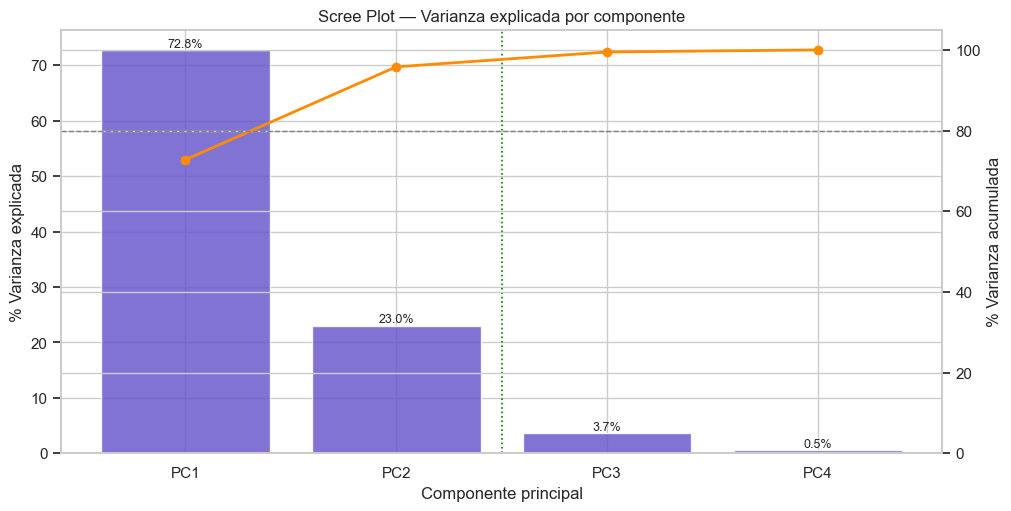

In [210]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
pca_iris.scree_plot(ax=ax)
plt.show()

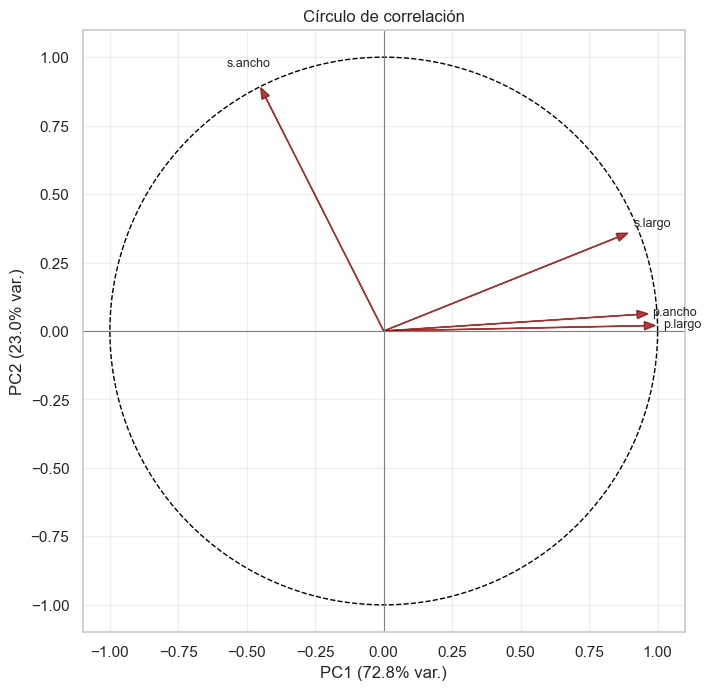

Correlación de cada variable con los componentes:
           PC1   PC2   PC3   PC4
variable                        
s.largo   0.89  0.36 -0.28 -0.04
s.ancho  -0.45  0.89  0.09  0.02
p.largo   0.99  0.02  0.05  0.12
p.ancho   0.96  0.06  0.24 -0.08


In [211]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
pca_iris.circulo_correlacion(ejes=(1, 2), ax=ax)
plt.show()

print('Correlación de cada variable con los componentes:')
print(pca_iris.col_correlations.round(2))

In [212]:
N_DIM = 2
coords_iris = pca_iris.row_coords.iloc[:, :N_DIM]
C_iris = coords_iris.values

print(f'Dimensiones conservadas: {N_DIM}')
print(f'Varianza acumulada: {pca_iris.varianza_acumulada[N_DIM-1]:.2f}%')
print(f'Matriz para el clustering: {C_iris.shape[0]} flores × {C_iris.shape[1]} componentes')

Dimensiones conservadas: 2
Varianza acumulada: 95.80%
Matriz para el clustering: 150 flores × 2 componentes


### Interpretación

El PCA de Iris es un caso de libro: **PC1 explica 72.8%** y **PC2 23.0%**, o sea que dos componentes acumulan el **95.8%** de la información. Prácticamente no se pierde nada al pasar de 4 dimensiones a 2.

El criterio de la varianza acumulada es aquí el que manda: 95.8% es un nivel altísimo, y las dos componentes restantes juntas aportan un 4.2% que es básicamente ruido. Kaiser sería más estricto (solo PC1 tiene eigenvalor mayor a 1, con 2.911, mientras PC2 se queda en 0.921), pero quedarse con una sola dimensión sería absurdo: se perdería el 27% de la información y no se podría hacer una visualización bidimensional. Con PC2 tan cerca del umbral, **se conservan 2 componentes**.

El círculo de correlación explica qué mide cada eje: **PC1** está construido por el largo de pétalo (0.99), el ancho de pétalo (0.96) y el largo de sépalo (0.89) — es un eje de **tamaño general de la flor**. **PC2** es casi puramente el ancho de sépalo (0.89), la única variable que no va con las demás.

## e) y f) K-Means y elección de k

Se usa **K-Means** sobre las dos componentes: los grupos que se ven en el plano son compactos y más o menos redondeados, que es justo el escenario donde K-Means funciona bien. Para elegir k se prueban valores de 2 a 6 con el codo de Jambú y el índice de silueta, **sin mirar la especie real**.

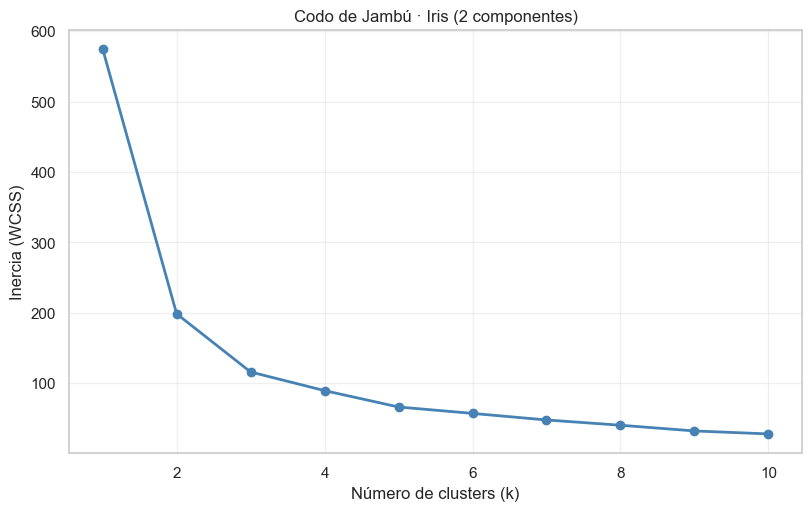

,k,inercia,reduccion_%
0,1,574.8,NaN
1,2,198.7,65.4
2,3,116.1,41.6
3,4,89.6,22.8
4,5,66.3,26.0
5,6,57.2,13.7
6,7,48.0,16.1
7,8,40.1,16.5
8,9,32.4,19.2
9,10,28.1,13.3


In [213]:
fig = codo_jambu(C_iris, max_k=10)
plt.title('Codo de Jambú · Iris (2 componentes)')
plt.show()

inercias_iris = [KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(C_iris).inertia_ for k in range(1, 11)]
tabla_iris = pd.DataFrame({'k': range(1, 11), 'inercia': np.round(inercias_iris, 1)})
tabla_iris['reduccion_%'] = (-tabla_iris['inercia'].pct_change() * 100).round(1)
tabla_iris

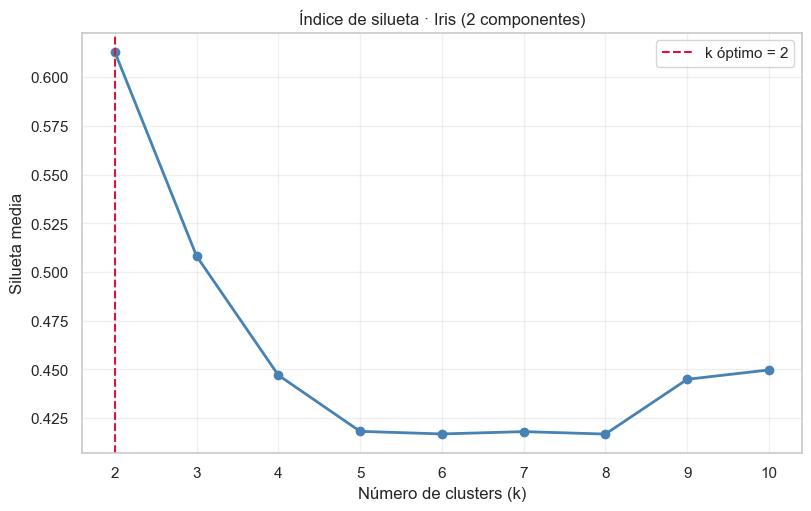

k con la silueta más alta: 2
  k = 2  →  silueta = 0.6130
  k = 3  →  silueta = 0.5082
  k = 4  →  silueta = 0.4470
  k = 5  →  silueta = 0.4161
  k = 6  →  silueta = 0.4170


In [214]:
fig, K_SIL_IRIS = silhouette_kmeans(C_iris, max_k=10)
plt.title('Índice de silueta · Iris (2 componentes)')
plt.show()

print(f'k con la silueta más alta: {K_SIL_IRIS}')
for k in range(2, 7):
    etq = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit_predict(C_iris)
    print(f'  k = {k}  →  silueta = {silhouette_score(C_iris, etq):.4f}')

### Interpretación

Los dos criterios **no coinciden**, y eso ya es un hallazgo:

- El **codo de Jambú** apunta a **k = 3**: la inercia cae 65% de 1 a 2 clusters y todavía un 42% de 2 a 3, pero de 3 a 4 la reducción baja a 23% y a partir de ahí las caídas se quedan en ese rango (entre 13% y 26%) sin ningún quiebre nuevo, o sea que después de 3 ya no se gana estructura, solo se parten grupos existentes.
- El **índice de silueta** prefiere **k = 2** (0.613) por encima de k = 3 (0.508).

La explicación es que con k = 2 el algoritmo separa un grupo muy despegado del resto y eso premia la silueta, mientras con k = 3 tiene que partir una nube más compacta y las fronteras quedan más apretadas. Ambos valores son defendibles, pero se trabaja con **k = 3** porque el codo (criterio de compactación) lo señala con claridad y la silueta de 0.508 sigue siendo un valor bueno, bastante por encima del umbral de 0.4 visto en clase.

Los otros parámetros del algoritmo (los mismos que en el Caso 1) se fijan así: **`n_init=20`** porque K-Means es estocástico (arranca con centroides aleatorios) y correr 20 inicializaciones distintas y quedarse con la de menor inercia evita caer en un mal arranque; **`random_state=42`** para que el resultado sea reproducible, ya que si no la numeración de los clusters e incluso su composición podrían cambiar entre corridas. El `max_iter` se deja en su valor por defecto (300): con 150 observaciones en dos dimensiones el algoritmo converge en pocas iteraciones, muy lejos de ese límite.

In [215]:
K_IRIS = 3

kmedias_iris = KMeans(n_clusters=K_IRIS, random_state=SEED, n_init=20)
cluster_iris = kmedias_iris.fit_predict(C_iris)
iris['cluster'] = cluster_iris

# Solución alternativa con k = 2, para comparar en el inciso i)
cluster_iris_k2 = KMeans(n_clusters=2, random_state=SEED, n_init=20).fit_predict(C_iris)

print(f'K-Means con k = {K_IRIS}')
print('Tamaño de cada cluster:')
print(pd.Series(cluster_iris).value_counts().sort_index())

K-Means con k = 3
Tamaño de cada cluster:
0    53
1    50
2    47
Name: count, dtype: int64


## g) Evaluación de la calidad con el índice de silueta

In [216]:
sil_iris = silhouette_score(C_iris, cluster_iris)
sil_vals_iris = silhouette_samples(C_iris, cluster_iris)

print(f'Silueta media (k = {K_IRIS}): {sil_iris:.4f}')
print(f'Silueta media (k = 2):     {silhouette_score(C_iris, cluster_iris_k2):.4f}')
print('\nSilueta media por cluster:')
print(pd.Series(sil_vals_iris).groupby(cluster_iris).mean().round(3))
print(f'\nObservaciones con silueta negativa (mal clasificadas): {(sil_vals_iris < 0).sum()}')

Silueta media (k = 3): 0.5082
Silueta media (k = 2):     0.6130

Silueta media por cluster:
0    0.441
1    0.652
2    0.431
dtype: float64

Observaciones con silueta negativa (mal clasificadas): 0


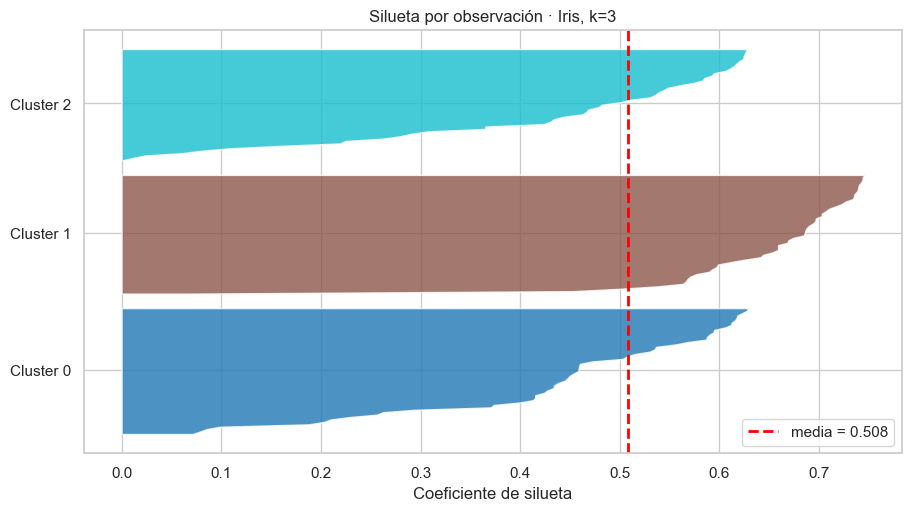

In [217]:
# Gráfico de silueta
clusters_i = sorted(np.unique(cluster_iris))
colores_i = plt.cm.tab10(np.linspace(0, 1, len(clusters_i)))

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
y = 0
yticks = []
for i, c in enumerate(clusters_i):
    vals = np.sort(sil_vals_iris[cluster_iris == c])
    ax.fill_betweenx(range(y, y + len(vals)), 0, vals, facecolor=colores_i[i], alpha=0.8)
    yticks.append(y + len(vals) / 2)
    y += len(vals) + 5

ax.axvline(sil_iris, color='red', linestyle='--', linewidth=2, label=f'media = {sil_iris:.3f}')
ax.set_yticks(yticks)
ax.set_yticklabels([f'Cluster {c}' for c in clusters_i])
ax.set_xlabel('Coeficiente de silueta')
ax.set_title(f'Silueta por observación · Iris, k={K_IRIS}')
ax.legend()
plt.show()

### Interpretación

La silueta media con k = 3 es **0.508**, un valor sólido y muy por encima del 0.29 que dio el caso del vino: aquí sí hay grupos con identidad propia. El detalle por cluster muestra la diferencia entre ellos: el cluster 1 promedia **0.652** y su bloque es ancho y uniforme, señal de un grupo muy bien separado, mientras los clusters 0 y 2 se quedan en 0.441 y 0.431 y tienen la forma "de cuchillo" descrita en clase, con observaciones que bajan hasta valores cercanos a 0: flores que quedan justo en la frontera entre esos dos grupos.

No hay **ninguna** silueta negativa, o sea que no hay una sola observación que estuviera mejor ubicada en otro cluster que en el propio. La estructura es real; lo que pasa es que dos de los tres grupos son vecinos muy cercanos.

## h) Visualización bidimensional de los clusters

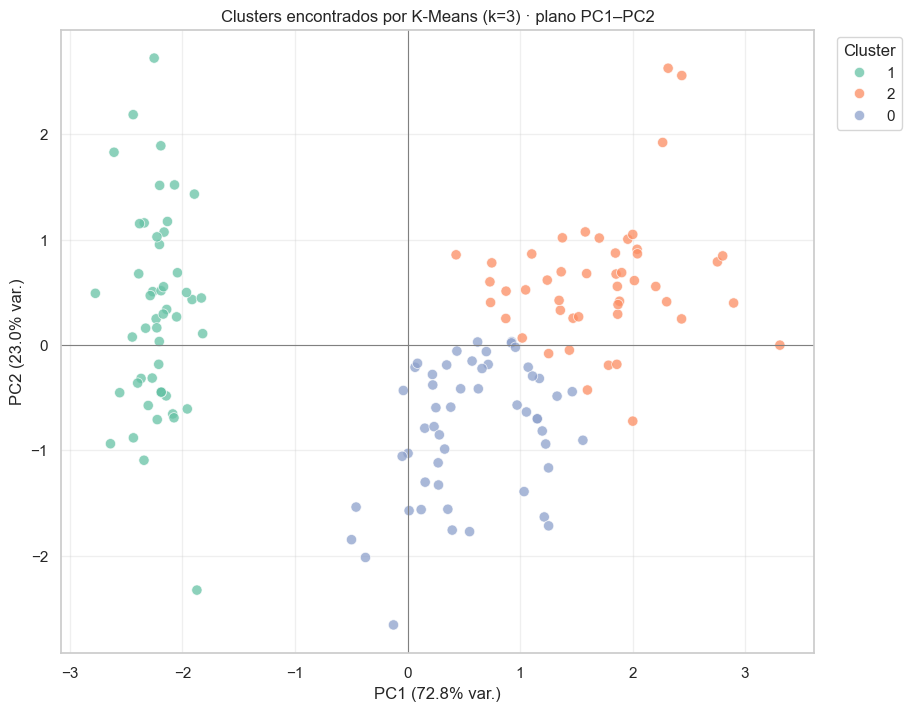

In [218]:
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
pca_iris.plano_principal(hue=pd.Series(cluster_iris, name='Cluster').astype(str), ejes=(1, 2), ax=ax)
ax.set_title(f'Clusters encontrados por K-Means (k={K_IRIS}) · plano PC1–PC2')
plt.show()

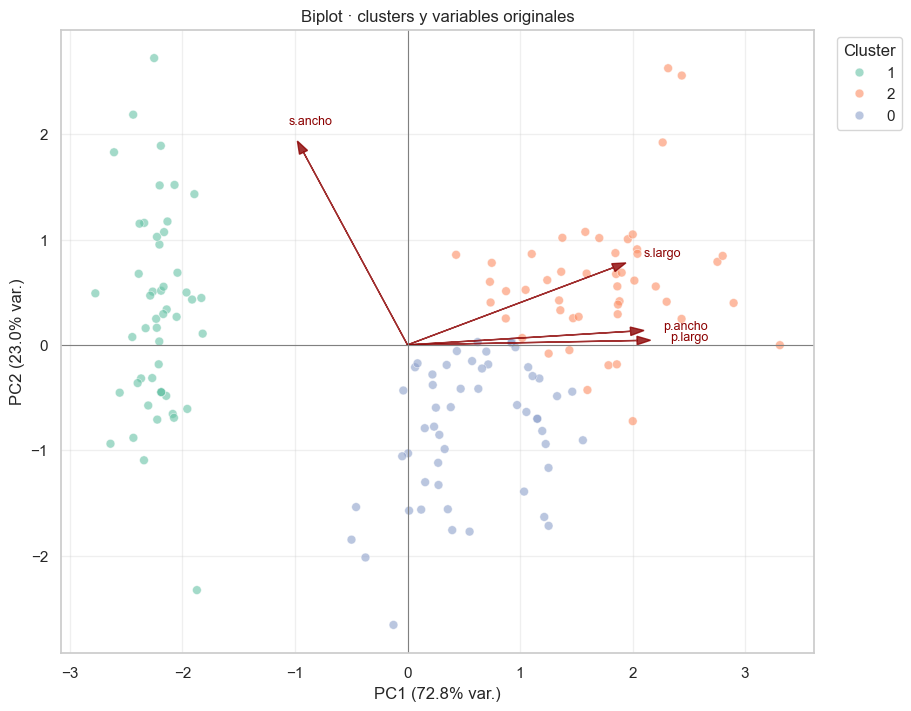

In [219]:
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
pca_iris.biplot(hue=pd.Series(cluster_iris, name='Cluster').astype(str), ejes=(1, 2), ax=ax)
ax.set_title('Biplot · clusters y variables originales')
plt.show()

In [220]:
# Coordenada media de cada cluster en el plano principal: dice qué eje separa a cuáles
centros_pc_iris = coords_iris.groupby(cluster_iris).mean()
print('Centroide de cada cluster en las 2 componentes:')
print(centros_pc_iris.round(2))

# Los clusters 0 y 2 son los que comparten frontera: se compara su separación en cada eje
print()
print('Separación entre los clusters vecinos (0 y 2) en cada componente:')
print((centros_pc_iris.loc[2] - centros_pc_iris.loc[0]).abs().round(2))

Centroide de cada cluster en las 2 componentes:
    PC1   PC2
0  0.57 -0.81
1 -2.22  0.29
2  1.72  0.60

Separación entre los clusters vecinos (0 y 2) en cada componente:
PC1    1.16
PC2    1.41
dtype: float64


Medias por cluster (cm):
         s.largo  s.ancho  p.largo  p.ancho
cluster                                    
0           5.80     2.67     4.37     1.41
1           5.01     3.42     1.46     0.24
2           6.78     3.10     5.51     1.97


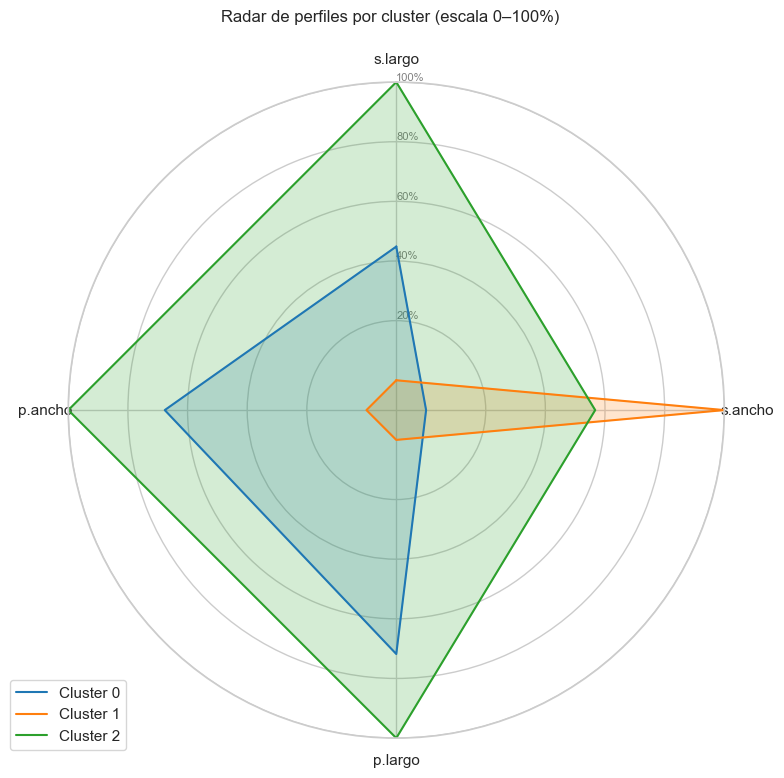

In [221]:
# Perfil de cada cluster en las variables originales
centros_iris = iris.groupby('cluster')[VARS_IRIS].mean()
print('Medias por cluster (cm):')
print(centros_iris.round(2))

fig = radar_plot(centros_iris.values, list(VARS_IRIS))
plt.show()

### Interpretación

En el plano PC1–PC2 se ve un grupo **totalmente despegado** a la izquierda y dos grupos pegados a la derecha, separados por una frontera sin espacio vacío entre ellos. Eso explica de dónde venía la discrepancia entre el codo y la silueta: si solo se pide k = 2, el algoritmo corta por el espacio vacío y obtiene la partición más "limpia" posible.

El biplot y las medias muestran de qué se trata cada grupo. El cluster aislado tiene pétalos diminutos (1.46 cm de largo, 0.24 de ancho) y los sépalos más anchos; los otros dos se diferencian sobre todo por tamaño: uno con pétalos de 4.37 cm y otro con pétalos de 5.51 cm y flores en general más grandes.

Vale mirar con cuidado **qué eje separa qué**, porque no es lo mismo en los dos cortes. El grupo aislado se despega por **PC1** (su centroide está en −2.22 frente a 0.57 y 1.72 de los otros dos): ahí manda el tamaño del pétalo. Pero entre los dos grupos de la derecha la frontera es **diagonal y con más peso en PC2**: sus centroides se separan 1.16 en PC1 y **1.41 en PC2**, o sea que el ancho de sépalo pesa incluso más que el tamaño. En el gráfico se ve claro: uno de los grupos queda arriba y el otro abajo, no uno a la izquierda del otro.

## i) y j) Comparación con las especies reales

In [222]:
# La especie se usa aquí por primera vez, solo para evaluar el resultado
contingencia = pd.crosstab(iris['cluster'], iris['tipo'])
print('Tabla de contingencia — clusters (k=3) vs especies reales:')
print(contingencia)

coincidencias = contingencia.max(axis=1).sum()
print(f'\nCoincidencia con la especie dominante de cada cluster: {coincidencias}/{len(iris)} '
      f'({coincidencias/len(iris)*100:.1f}%)')

Tabla de contingencia — clusters (k=3) vs especies reales:
tipo     setosa  versicolor  virginica
cluster                               
0             0          39         14
1            50           0          0
2             0          11         36

Coincidencia con la especie dominante de cada cluster: 125/150 (83.3%)


In [223]:
print('Tabla de contingencia con la solución alternativa de k=2:')
print(pd.crosstab(cluster_iris_k2, iris['tipo']))

Tabla de contingencia con la solución alternativa de k=2:
tipo   setosa  versicolor  virginica
row_0                               
0          50           0          0
1           0          50         50


In [ ]:
# Medidas promedio por especie
print('Promedio de las medidas originales por ESPECIE:')
print(iris.groupby('tipo')[VARS_IRIS].mean().round(2))

# Rangos de las medidas de pétalo: muestran el solapamiento real entre las especies
print('\nRango de p.largo y p.ancho por especie:')
print(iris.groupby('tipo')[['p.largo', 'p.ancho']].agg(['min', 'max']))

Promedio de las medidas originales por ESPECIE:
            s.largo  s.ancho  p.largo  p.ancho
tipo                                          
setosa         5.01     3.42     1.46     0.24
versicolor     5.94     2.77     4.26     1.33
virginica      6.59     2.97     5.55     2.03

Rango de p.largo y p.ancho por especie:
           p.largo      p.ancho     
               min  max     min  max
tipo                                
setosa         1.0  1.9     0.1  0.6
versicolor     3.0  5.1     1.0  1.8
virginica      4.5  6.9     1.4  2.5


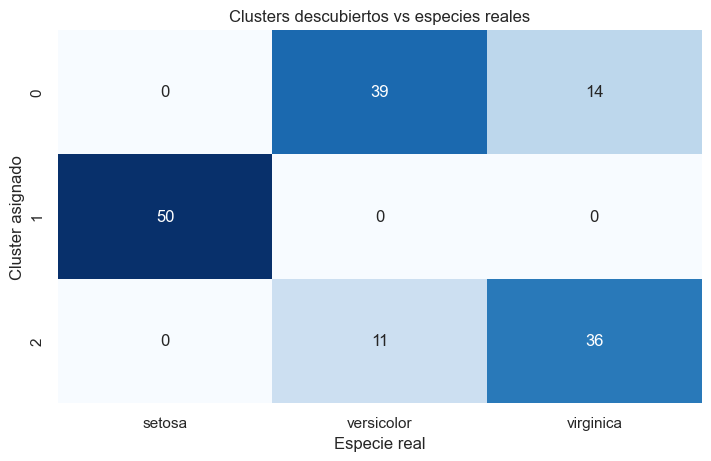

In [225]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
sns.heatmap(contingencia, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Clusters descubiertos vs especies reales')
ax.set_xlabel('Especie real')
ax.set_ylabel('Cluster asignado')
plt.show()

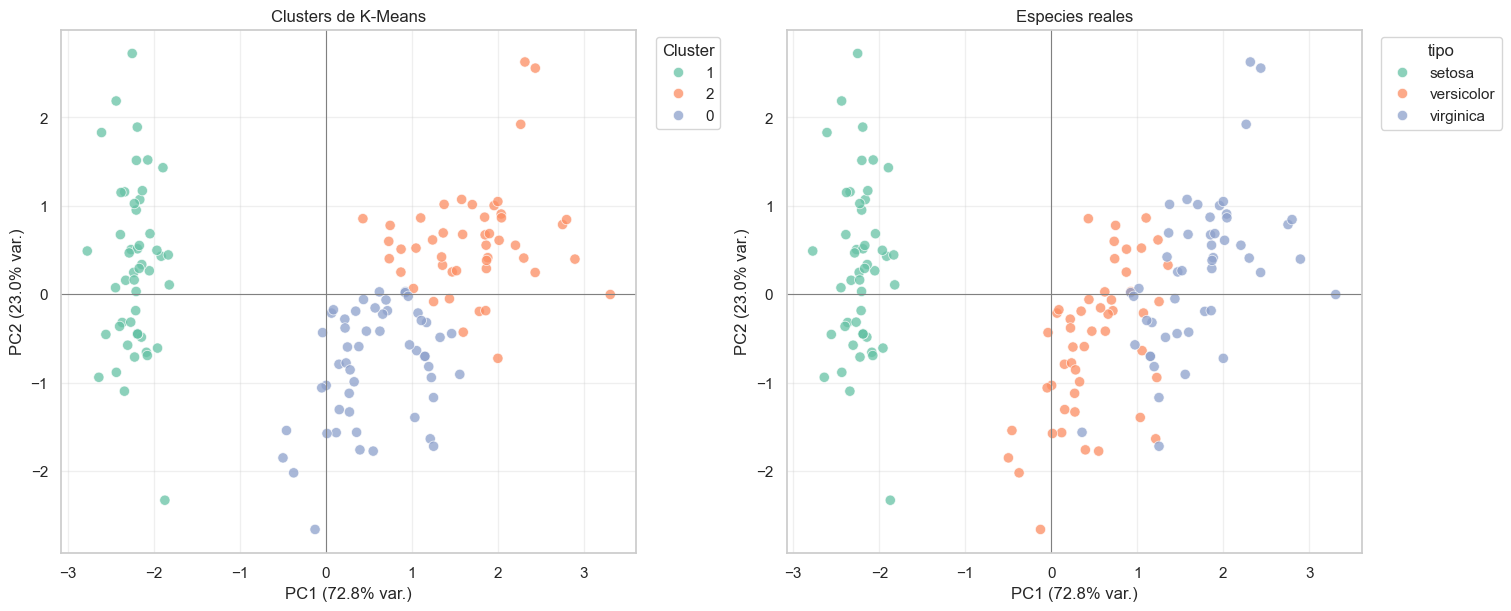

In [ ]:
# Los mismos datos coloreados por especie real
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
pca_iris.plano_principal(hue=pd.Series(cluster_iris, name='Cluster').astype(str), ejes=(1, 2), ax=axes[0])
axes[0].set_title('Clusters de K-Means')
pca_iris.plano_principal(hue=iris['tipo'], ejes=(1, 2), ax=axes[1])
axes[1].set_title('Especies reales')
plt.show()

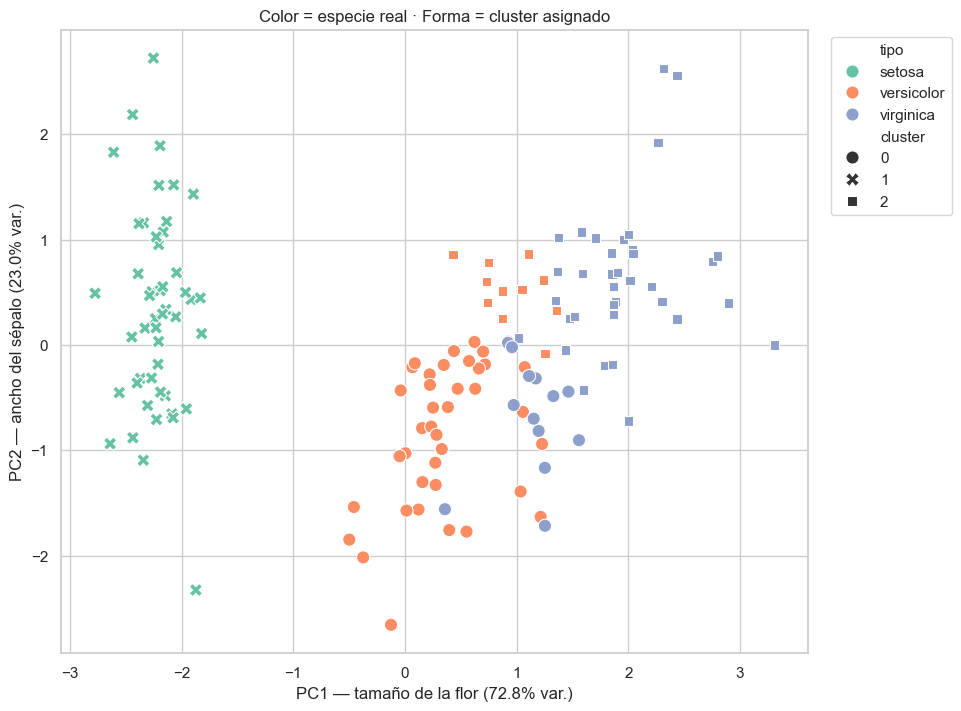

In [227]:
# Las dos informaciones en un solo gráfico: color = especie real, forma = cluster asignado
fig, ax = plt.subplots(figsize=(9.5, 7), constrained_layout=True)
sns.scatterplot(x=C_iris[:, 0], y=C_iris[:, 1], hue=iris['tipo'],
                style=pd.Series(cluster_iris, name='cluster'), s=90, ax=ax)
ax.set_xlabel(f'PC1 — tamaño de la flor ({pca_iris.varianza_explicada[0]:.1f}% var.)')
ax.set_ylabel(f'PC2 — ancho del sépalo ({pca_iris.varianza_explicada[1]:.1f}% var.)')
ax.set_title('Color = especie real · Forma = cluster asignado')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### Interpretación

La correspondencia es **alta pero no perfecta: 125 de 150 flores (83.3%)** caen en el cluster que corresponde a su especie dominante. El detalle importa:

- **Setosa** queda capturada de forma **perfecta**: las 50 flores, y solo esas 50, forman un cluster entero. Es el grupo despegado del gráfico.
- **Versicolor y virginica se mezclan**: uno de los clusters tiene 39 versicolor y 14 virginica, y el otro 36 virginica y 11 versicolor. Las 25 flores mal ubicadas están todas en esa frontera.

Poniendo los dos gráficos lado a lado se ve exactamente **de dónde vienen esas 25 flores**, y es más interesante que un simple corrimiento: las dos fronteras están **giradas** una respecto a la otra. El algoritmo separó sus dos grupos de forma casi horizontal —uno arriba y otro abajo, o sea por ancho de sépalo (PC2)— mientras la diferencia real entre versicolor y virginica se apoya más en PC1: sus medias están en PC1 = 0.49 y 1.73 (una diferencia de 1.24) contra 0.81 de diferencia en PC2. K-Means partió la nube por donde había un hueco geométrico, que no era donde estaba la separación biológica.

No es un fallo del algoritmo: en las cuatro medidas de sépalo y pétalo esas dos especies **genuinamente se solapan**. Los rangos lo muestran sin ambigüedad: el largo de pétalo va de 3.0 a 5.1 cm en versicolor y de 4.5 a 6.9 cm en virginica, o sea que **se cruzan entre 4.5 y 5.1 cm**; con el ancho pasa lo mismo (1.0–1.8 contra 1.4–2.5, cruce entre 1.4 y 1.8). Ningún método basado solo en distancias puede separar del todo dos poblaciones cuyas medidas se traslapan, tal como se vio en clase al comparar PCA, t-SNE y UMAP sobre Iris.

Y hay un motivo extra para esos 25 errores: los promedios por especie muestran que el ancho de sépalo es casi idéntico en versicolor (2.77 cm) y virginica (2.97 cm). Como el algoritmo usó ese eje para separar sus dos grupos, estaba cortando por una variable que entre esas dos especies **no discrimina**.

La solución de k = 2 aporta la otra mitad de la historia: separa setosa del resto de forma **impecable** (50 contra 100), y por eso su silueta era más alta. Un analista que solo hubiera mirado la silueta habría concluido que en Iris hay dos grupos, y desde el punto de vista de la geometría de los datos no estaría equivocado. Lo que muestra este ejercicio es que las métricas internas miden separación, no verdad biológica.

## k) Por qué no sería correcto usar la especie para entrenar el clustering

Porque el ejercicio dejaría de ser aprendizaje no supervisado. El clustering se define justamente por la **ausencia de etiqueta**: el objetivo es descubrir si los datos tienen estructura por sí solos, no reproducir una respuesta que ya se conoce. Si se le pasa la especie como variable de entrada, el algoritmo agruparía por esa columna (que separa perfecto por construcción) y el resultado no diría nada sobre las medidas de sépalo y pétalo, que es lo que se quería evaluar.

Sería además un razonamiento **circular** para la validación: no se puede usar la especie para formar los grupos y después usar esa misma especie para comprobar que los grupos son correctos. Al mantenerla afuera, la tabla de contingencia del inciso i) es una prueba independiente y con valor real: el 83.3% de coincidencia significa algo precisamente porque el algoritmo nunca vio esa información.

Y en la práctica, si la etiqueta existe y se quiere predecirla, la herramienta correcta es un modelo **supervisado** (KNN, árbol de decisión, regresión logística), no un clustering; usar el target en un método no supervisado es mezclar dos enfoques y quedarse sin las ventajas de ninguno.

## l) Conclusión del Caso 2

El aprendizaje no supervisado **recuperó la estructura de Iris casi por completo, sin ver una sola etiqueta**. El PCA comprimió las cuatro medidas en dos componentes que retienen el 95.8% de la información, y sobre ese plano K-Means con k = 3 logró un 83.3% de coincidencia con las especies reales y una silueta de 0.508.

El resultado tiene dos caras. Del lado fuerte: *setosa* fue identificada de forma perfecta, sin una sola flor mal ubicada, y el algoritmo reconstruyó por su cuenta que las flores se ordenan principalmente por tamaño de pétalo, la misma variable que un botánico usaría. Del lado de las limitaciones: *versicolor* y *virginica* no se pudieron separar bien porque **en estas cuatro variables realmente se solapan**, y 25 flores quedaron en el cluster equivocado. Ninguna métrica interna podía avisar de eso: la silueta incluso prefería k = 2, que era la partición geométricamente más limpia aunque biológicamente incompleta.

La lección técnica es esa última: las métricas internas dicen qué tan **separados** están los grupos, no si son los grupos "correctos", porque ese concepto no existe sin etiquetas. Un clustering es una herramienta exploratoria potente (aquí encontró tres grupos con sentido a partir de puras medidas) pero sus resultados hay que leerlos junto con el conocimiento del dominio. Si el interés fuera realmente separar versicolor de virginica, habría que traer más variables o pasar a un método supervisado.